# Learning to Search

**Learning** refers to the process of teaching algorithms to efficiently explore and navigate complex problem spaces to find solutions. Unlike traditional approaches where solutions are explicitly defined, learning-based search methods enable systems to adapt and improve their search strategies over time. This approach is particularly powerful in scenarios with vast or dynamic search spaces, such as optimization problems, or decision-making tasks. By leveraging techniques from **Machine Learning**, **Reinforcement Learning**, and **Deep Reinforcement Learning**, systems can learn to identify patterns, evaluate possible outcomes, and make informed decisions, ultimately enhancing their ability to solve problems autonomously and efficiently.

## Traditional Programming

In traditional software, **the programmer designs an algorithm that processes input, applies predefined rules, and generates output**. Every decision—such as determining game over, updating the score, or positioning the ball—is explicitly coded, with the program following rigid, hardcoded rules.

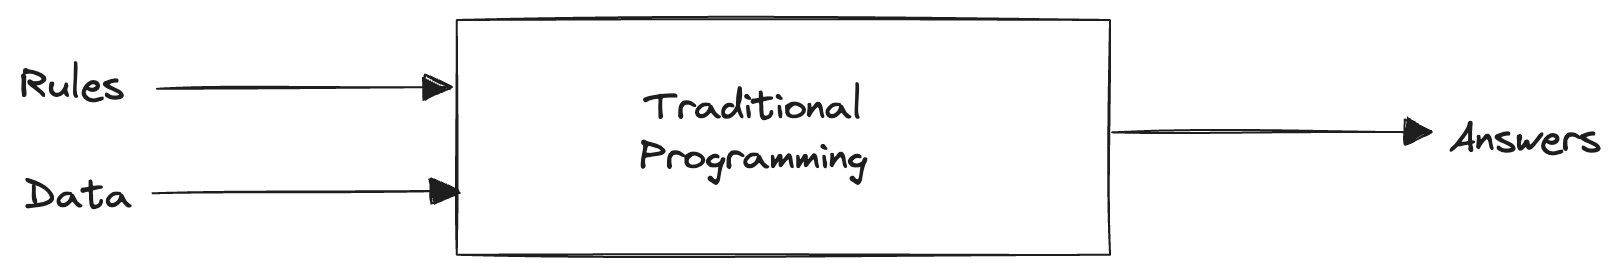

This approach is powerful but has limitations. As complexity grows, so does the code required, making it harder to manage. In many cases, **some scenarios are simply too complex or impractical to define and implement with traditional coding alone**. Consider **activity detection**, a task handled by smartwatches. The goal is to identify actions like walking, running, biking, or golfing using sensor data. Simple rules can distinguish walking from running based on speed, but more complex activities, like golfing, are harder to define with fixed thresholds. As activities become more nuanced, writing accurate rules becomes increasingly challenging:

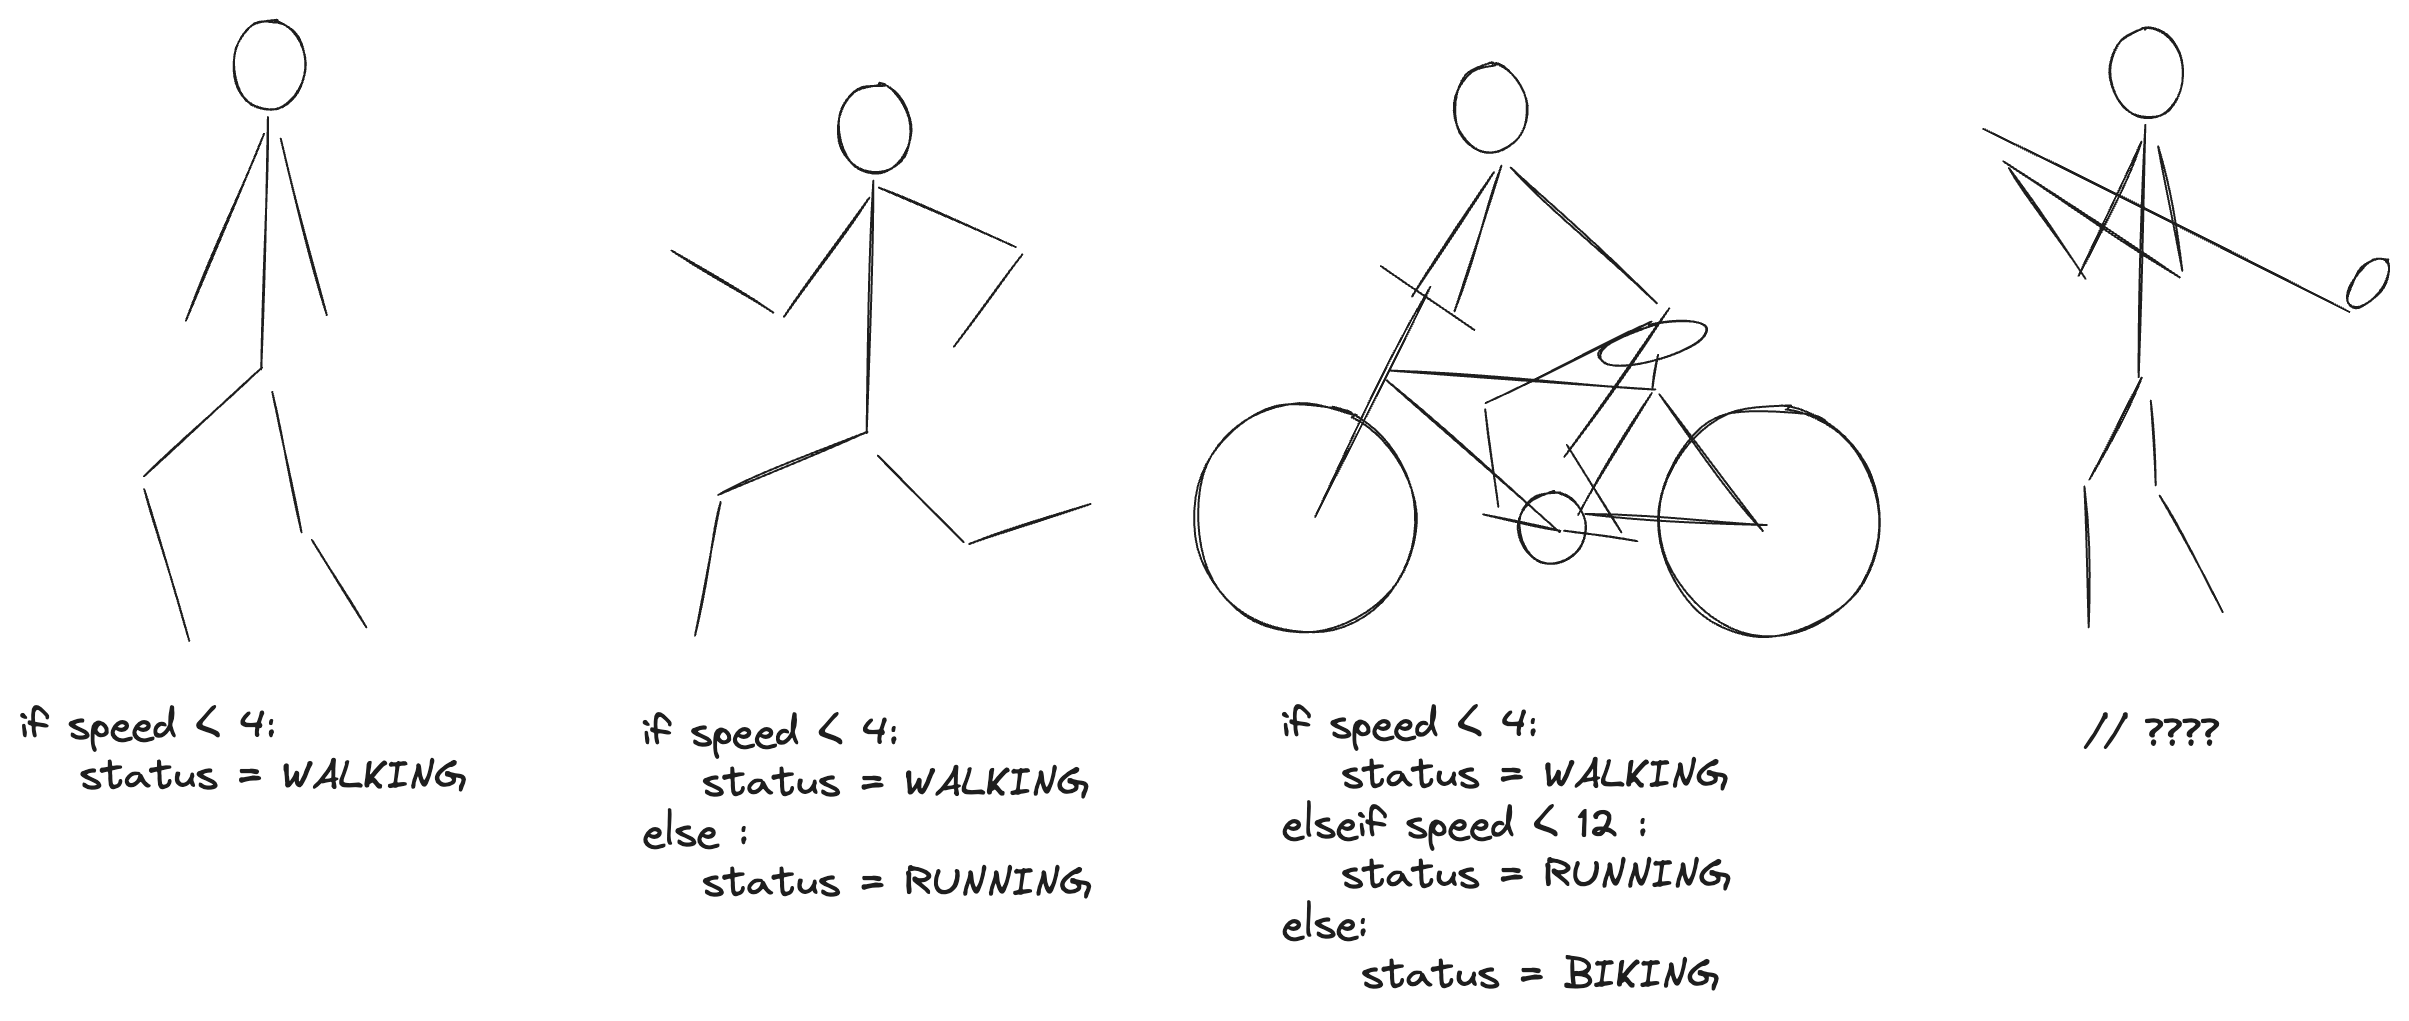

Rules can be overly simplistic and fail to capture the complexity of real-world scenarios. For example, a person running downhill might move faster than someone biking uphill, making speed alone unreliable. These **edge cases** highlight the **limitations of rule-based approaches**, which struggle to account for the nuances and variability of real-life activities.

## Learning

Instead of explicitly coding a solution, we enable the computer **to learn how to solve a problem**. Rather than manually defining rules, we provide the computer with data and corresponding answers, allowing it to **discover the rules** that connect them. This way, the computer **learns to generalize patterns**, eliminating the need to define every rule explicitly:

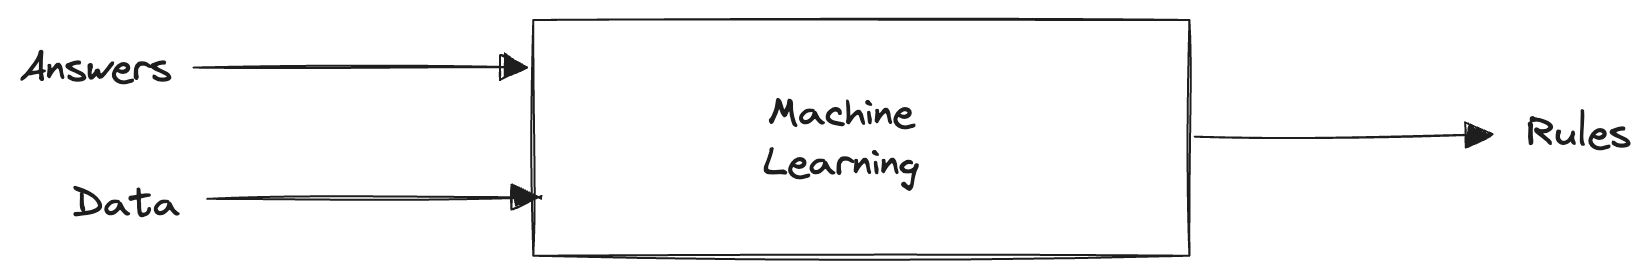

In the activity detection scenario, we can collect a large amount of labeled sensor data, indicating the activity the user is performing. By analyzing this data, the computer learns to identify patterns and relationships, automatically determining the rules that distinguish activities like walking, running, biking, or golfing. This removes the need for manually defining rules, as the computer uncovers them directly from the data:

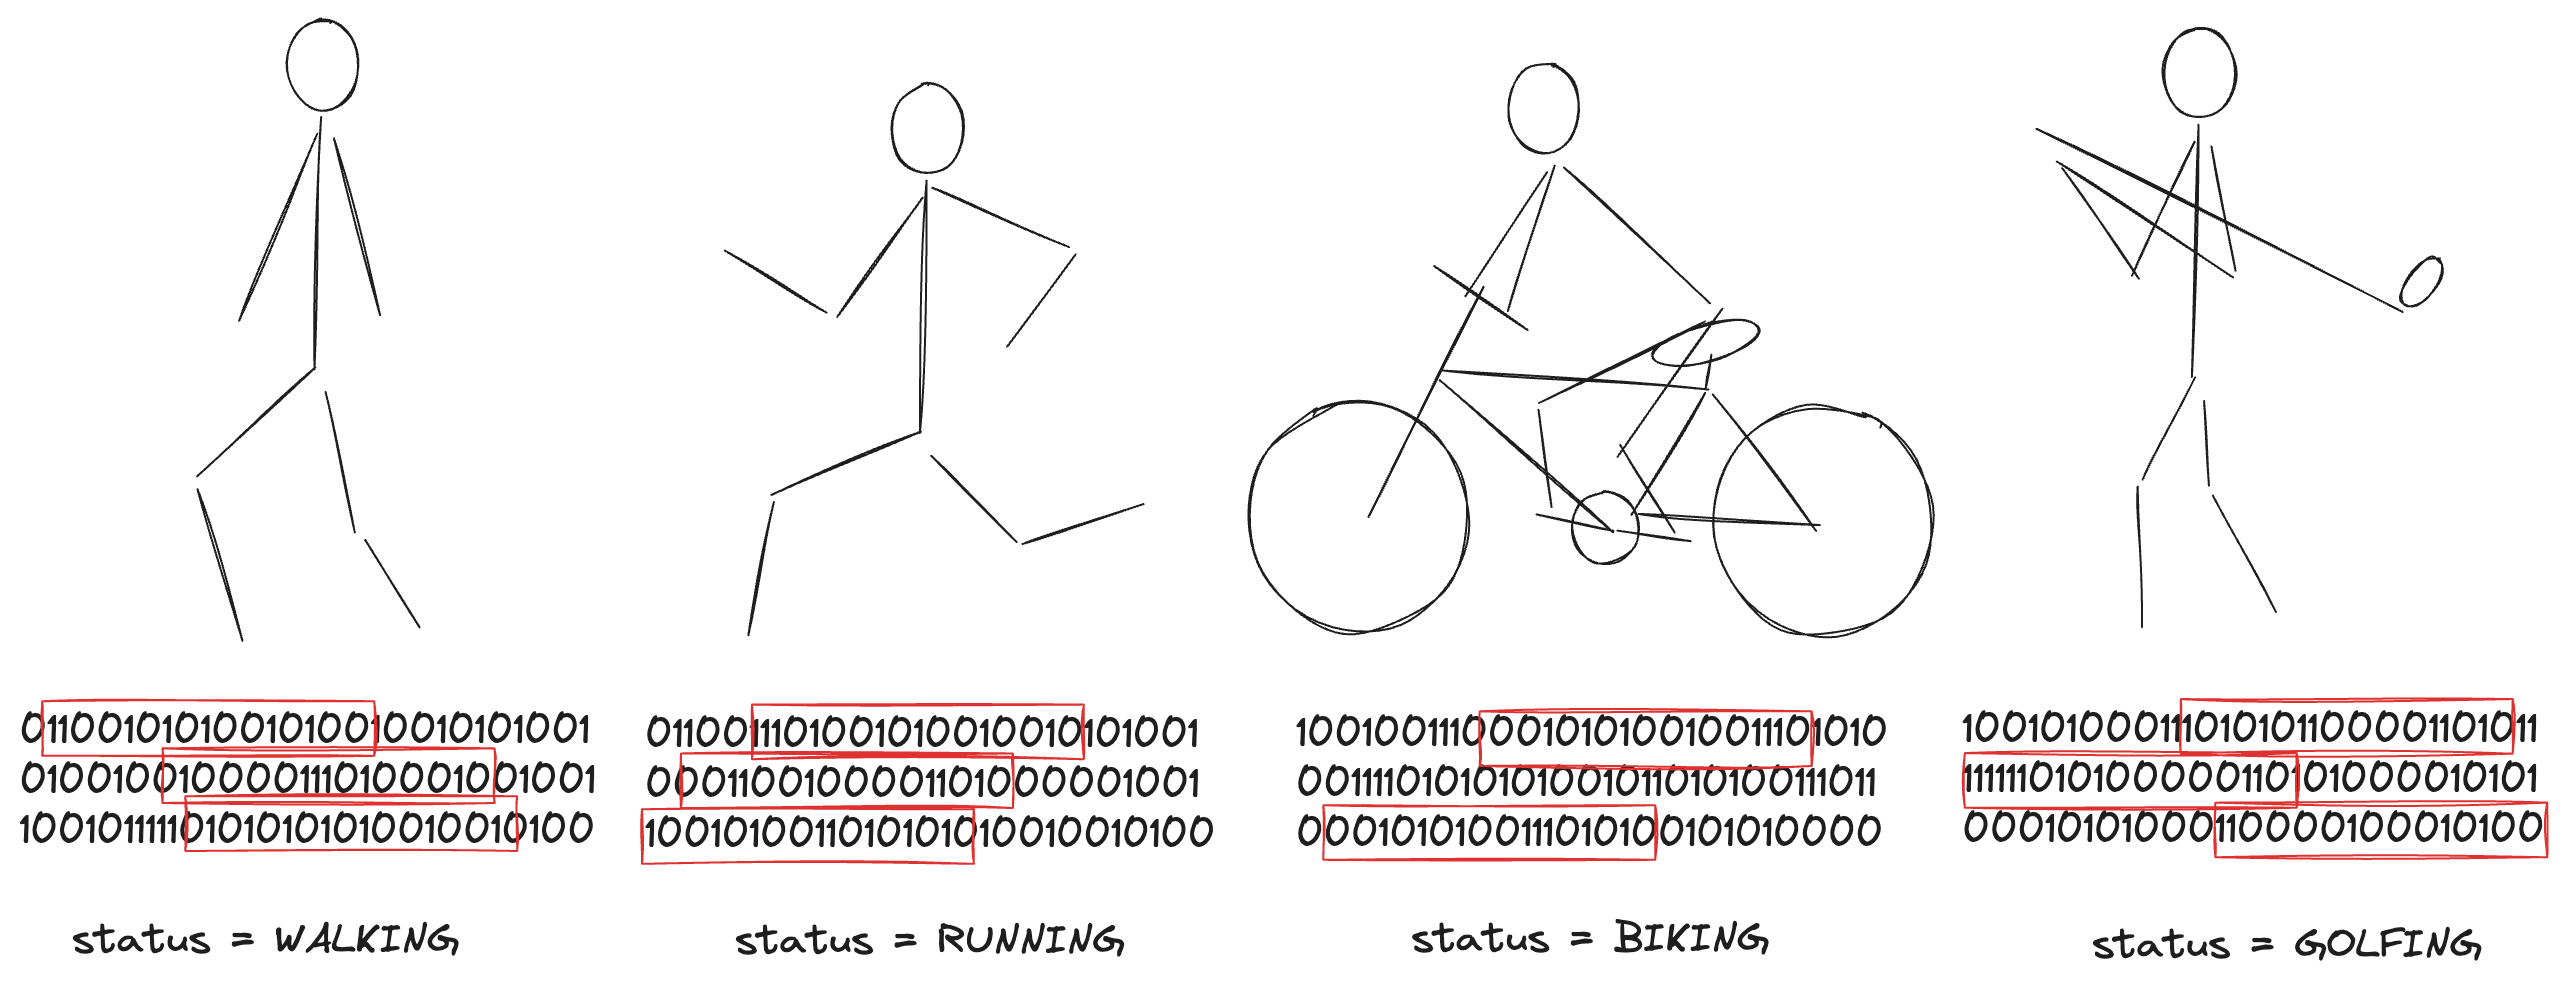

### Model

The computer starts by making **an initial guess** about the relationship between the data and labels. It then **evaluates the accuracy** of that guess by comparing it to the correct answer. Using this feedback, it **adjusts its approach** to improve the guess, building on previous learning. Through repeated iterations, **each guess improves upon the last**, enabling the computer **to learn from experience** and gradually converge on the best solution:

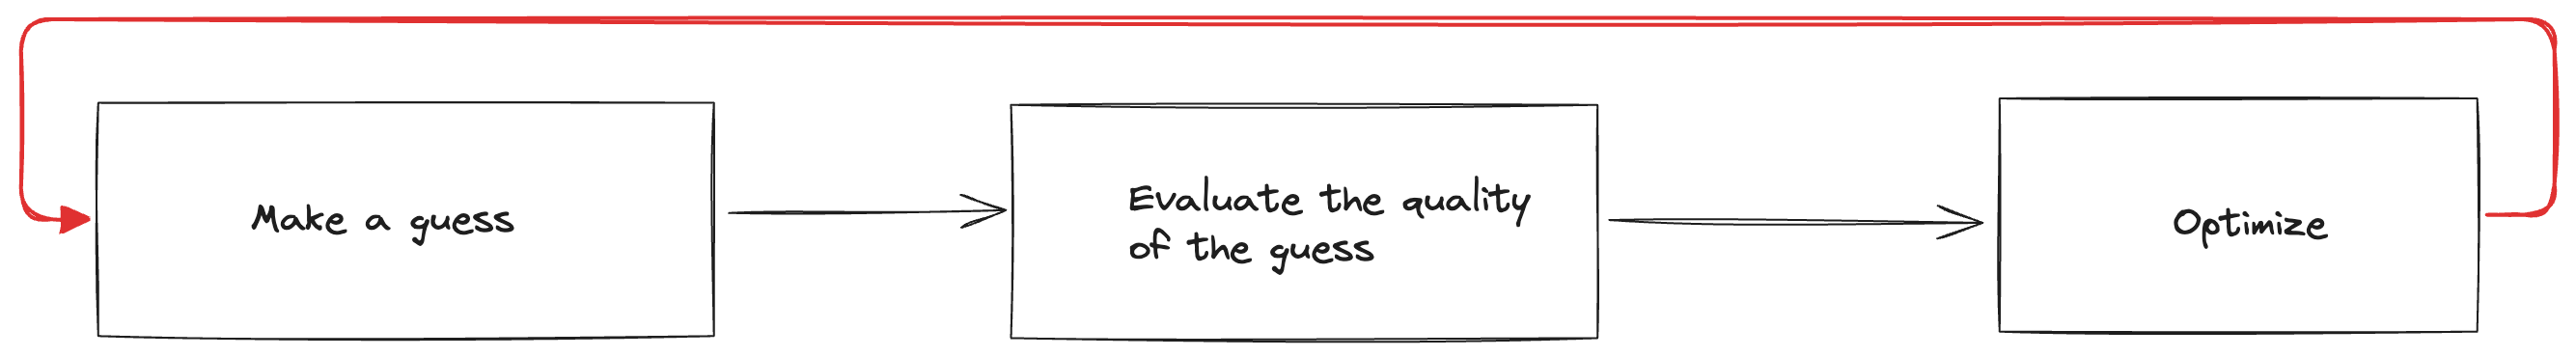

This process **builds a model** that can be used to **label new, unseen data**, a process called **inference**. A model is a **mathematical representation of the relationships between variables**:

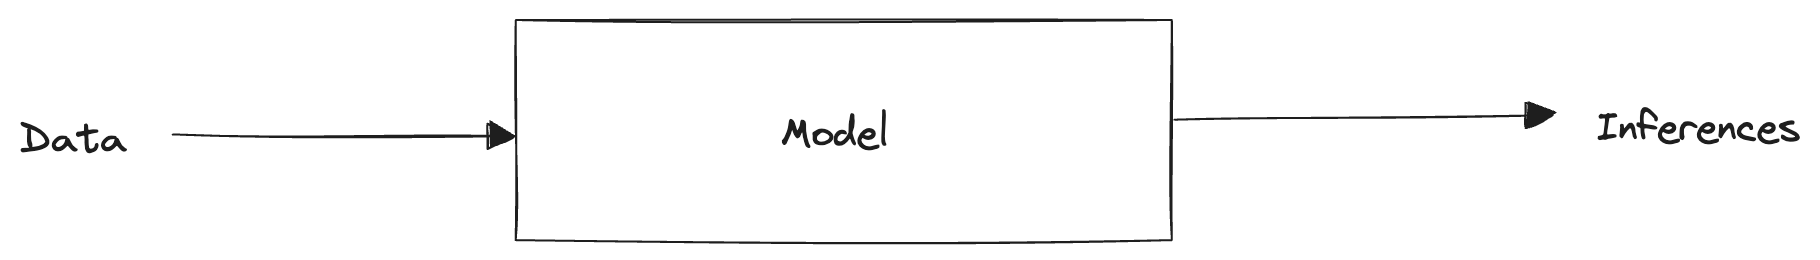

For example, a **business model** predicts future profit based on inputs like "number of users" and "ad revenue per user." A **cookbook recipe** connects inputs like "number of diners" and "level of hunger" to ingredient quantities. An **electronic circuit design** models output voltage based on inputs like supply voltage, resistance, and current. These models are built using different methods: business models often rely on **simple mathematical relationships**, recipes may be based on **trial and error**, and circuit models use **physical laws** like Ohm's and Kirchhoff's laws. **Each model provides a framework for making informed predictions based on relevant inputs.**

### Machine Learning

We’ll use the term **machine learning** to describe the process of creating and using models that are learned from data. The primary goal is to develop models that can predict outcomes for new, unseen data based on existing data. A widely recognized definition, provided by Tom Mitchell in [Machine Learning, 1998](http://www.cs.cmu.edu/~tom/mlbook.html):

> A computer program is said to learn from experience (E) with respect to some task (T) and some performance measure (P), if its performance on T, as measured  by P, improves with experience E.


For example, in a spam classification problem, the task (T) is to predict whether an email is spam or not. The experience (E) consists of labeled data, where emails are marked as spam or not spam. The performance measure (P) is the proportion of emails correctly classified by the model. As the program is exposed to more labeled data, its ability to classify emails improves, demonstrating learning from experience.

Creating a machine learning program involves **feeding data** (such as dashboard video and sensor readings from a car) along with **target outputs** (like throttle levels and steering angles) into **a specialized algorithm**. Through a process called **training**, the algorithm **learns from the data, discovers the underlying rules and builds a model** (a program capable of driving the car based on sensor inputs). This model can then process new data to make predictions, a process referred to as **inference**. This approach allows us to create systems that make predictions from complex data **without needing to fully understand all the complexities ourselves**. In essence, traditional programming involves automating tasks by writing explicit programs. In machine learning, the computer generates a program by learning patterns from the data.

### Types of Machine Learning

Machine learning approaches can be categorized as **supervised** (where the model learns from labeled data with correct answers), **unsupervised** (where there are no labels and the model finds patterns in the data), **semisupervised** (where only some of the data are labeled), and **reinforcement** (where the model makes predictions and receives feedback on its performance, improving over time):

| **Question**         	| **Supervised**               	| **Unsupervised**                	| **Reinforcement**                  	|
|----------------------	|------------------------------	|---------------------------------	|------------------------------------	|
| _Target_             	| f(x)=y                       	| x in X                          	| p(s)=a                             	|
| _Target (rephrased)_ 	| Predict outputs given inputs 	| Discover structure in data      	| Find an optimal behavior           	|
| _Data_               	| {(x,y)} supervisor's labels  	| {x} unlabelled data             	| {(s,a,r,s)} experience samples     	|
| _Output_             	| Classifier or regressor      	| Clusters or dimension reduction 	| Policies, value functions          	|
| _Key algorithms_     	| Neural networks, SVMs, etc.  	| k-means, PCA, etc.              	| Q-learning, Policy Gradients, etc. 	|

From the perspective of building agents, we are primarily interested in **reinforcement learning**, as it focuses on learning through interaction and feedback, however Machine Learning is important becouse it provide a way to implement the reinforcement learning algorithms in a scalable way.

## Reinforcement Learning

Reinforcement Learning is **a computational approach to learning through interaction**, where an agent learns to map situations to actions in order to maximize a numerical reward. The agent isn't told which actions to take but discovers the best actions by interacting with its **environment** (everything outside the agent) that it doesn't fully control. For example, when training a robot to pick up objects, the objects, tray, and external factors like wind are part of the environment. Even the robot arm is considered part of the environment, as it is subject to noise despite being controlled by the agent. This **boundary between agent and environment** is crucial: the agent's role is solely decision-making, while everything else is considered the environment:

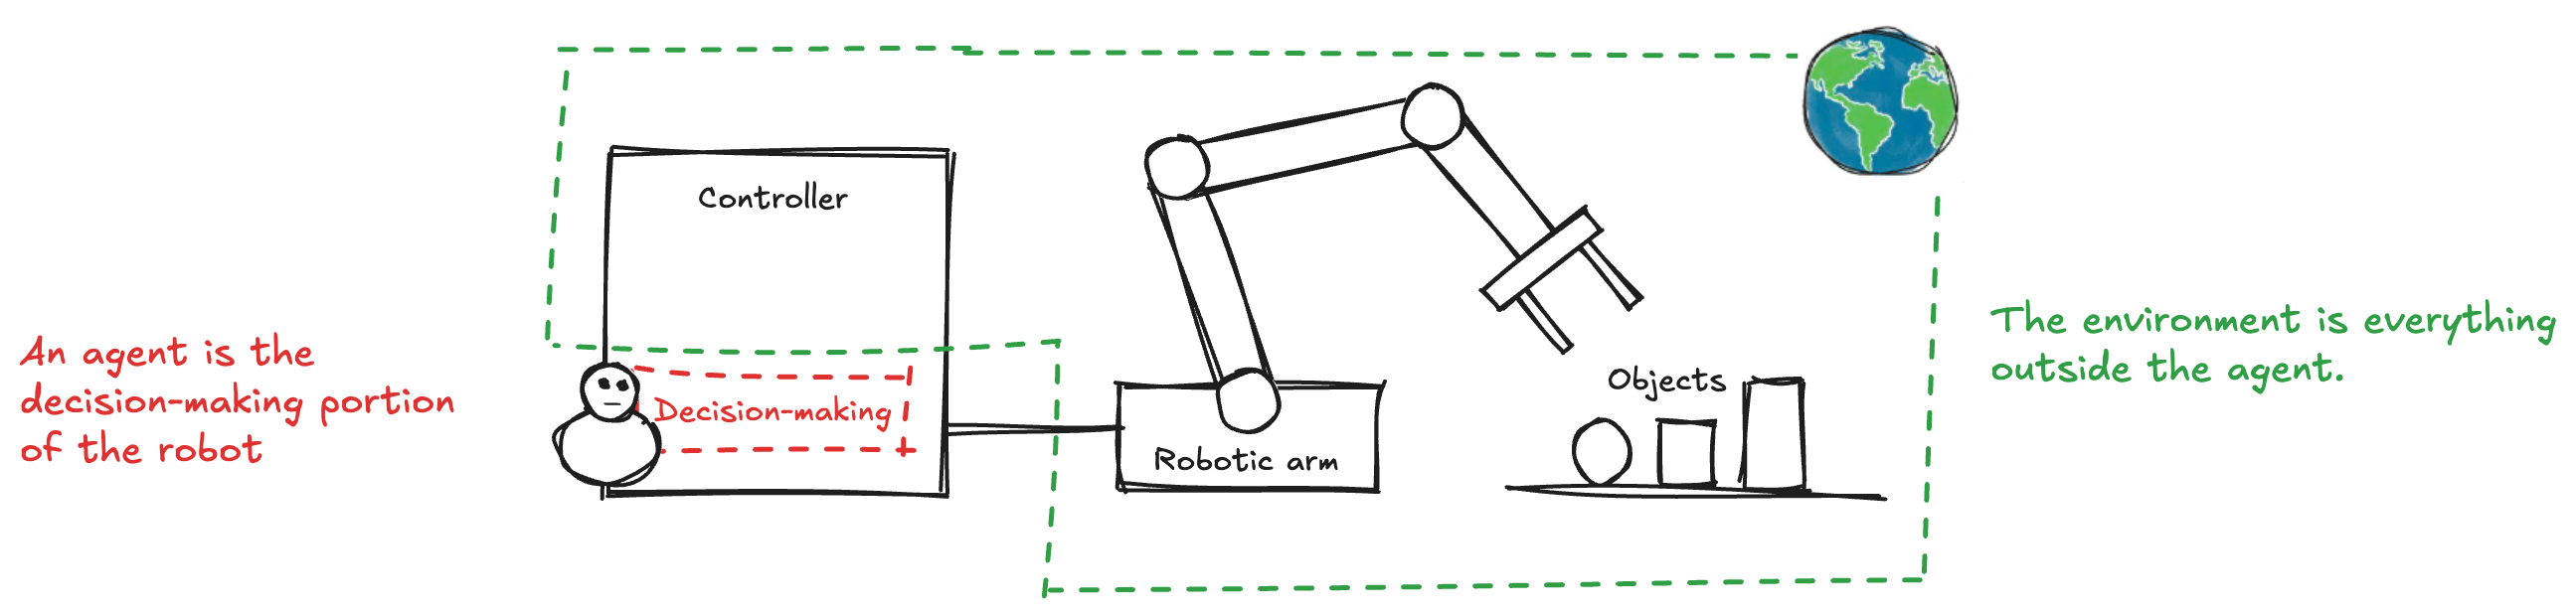

In challenging cases, actions can influence not only immediate rewards but also future situations and rewards. The key features of reinforcement learning are **trial-and-error search** and **delayed rewards**.

### Environment

The environment is represented by a **set of variables** relevant to the problem. In the robotic arm example, variables like the arm's location and velocity make up the environment. These variables and their possible values form the **state space**, with a **state** representing a specific instantiation of these values. Agents often don’t have access to the full state of the environment. Instead, they observe a subset of it, called an **observation**. For instance, the agent might only see camera images rather than the exact location of each object. Observations are derived from the state, and in literature, the terms state and observation are sometimes used interchangeably:

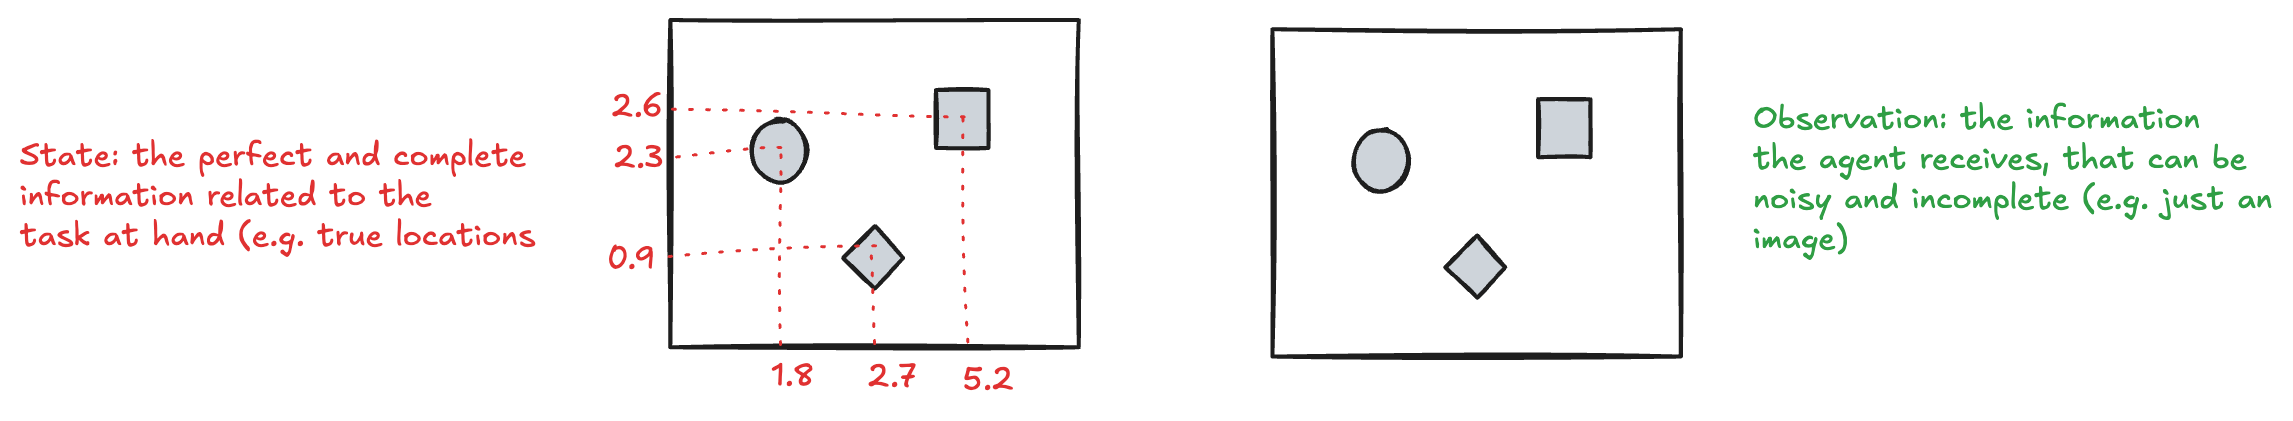

### Actions

At each state, the environment offers a **set of actions** for the agent to choose from. The agent influences the environment through these actions, which may lead to a change in state. The **transition function** governs this mapping. Additionally, the environment provides a **reward signal** based on the agent's action, governed by the **reward function**. Together, the transition and reward functions make up the **model** of the environment.

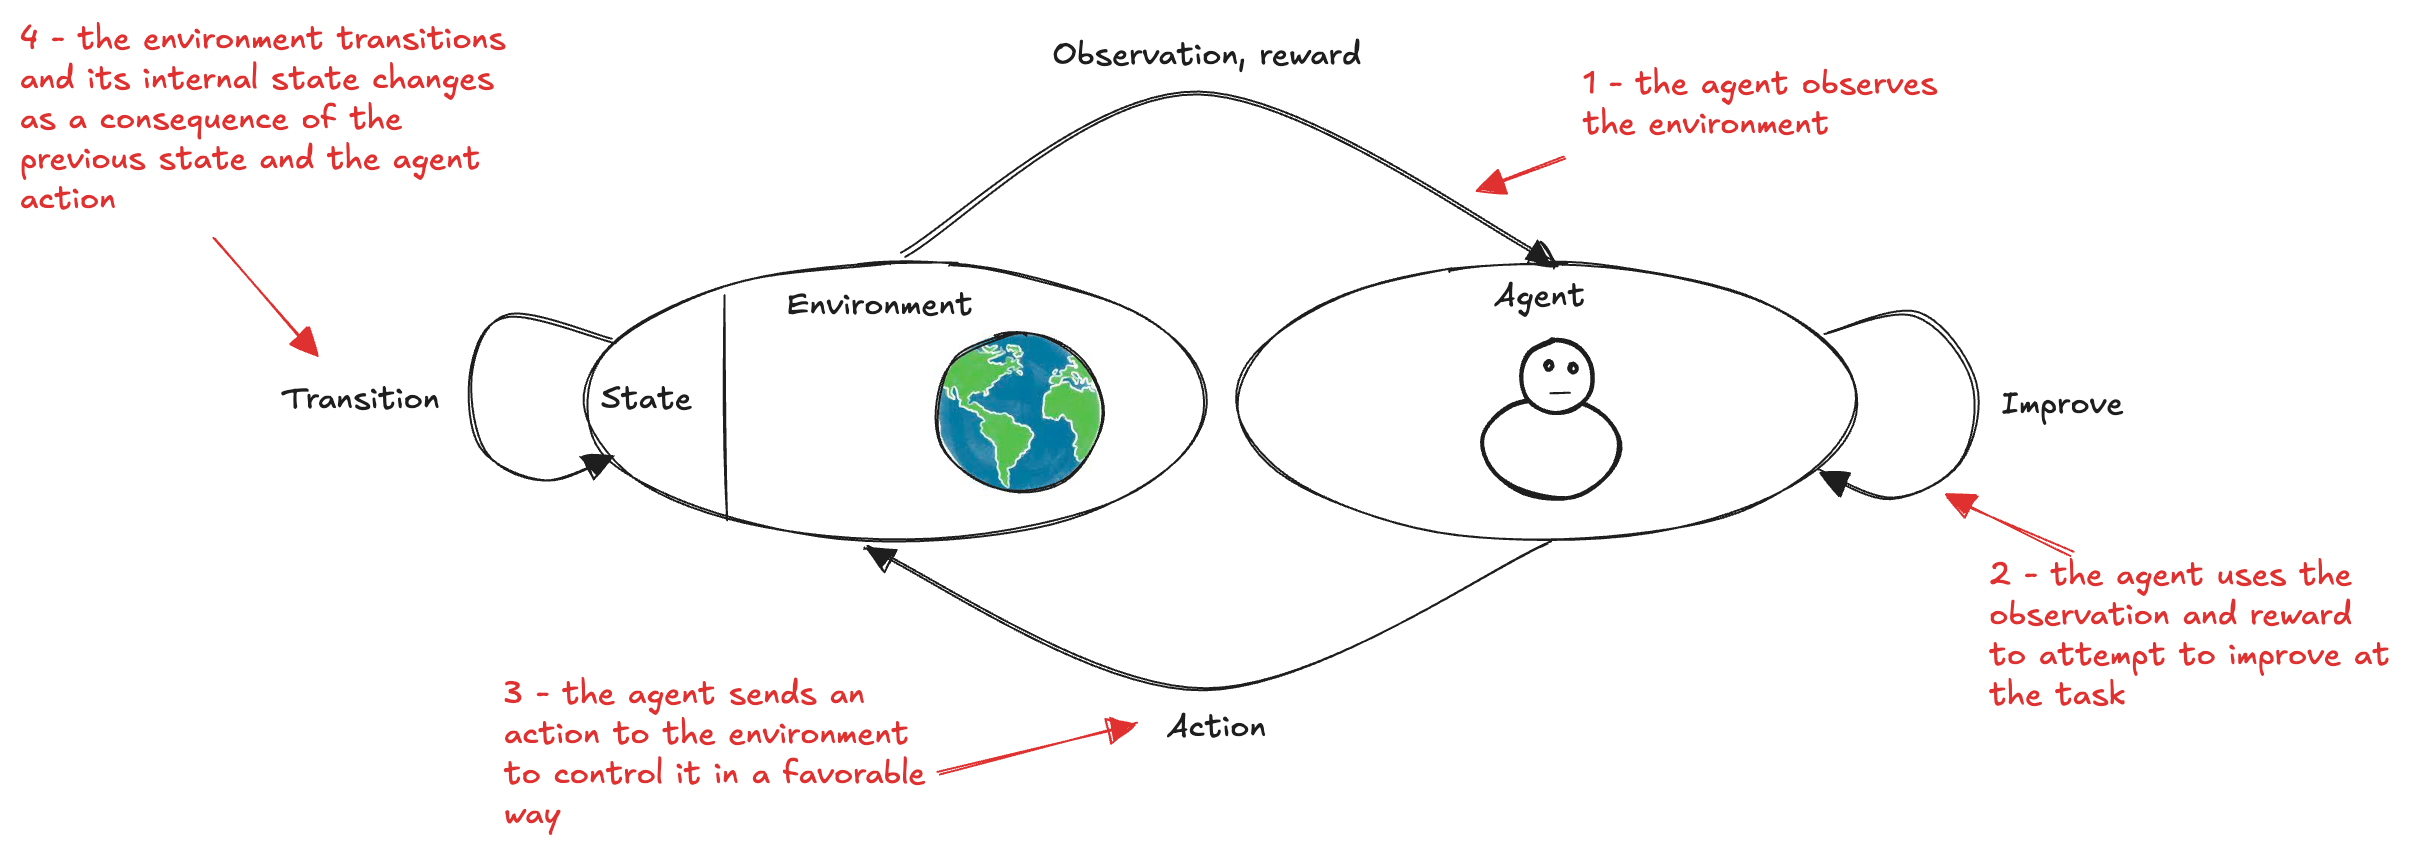

### Frozen Lake

Frozen Lake (FL) is a classic **grid-world environment** used in RL research. It features discrete state and action spaces, with four possible moves: left, down, right, and up. The goal is to navigate from a start location to a goal while avoiding holes:

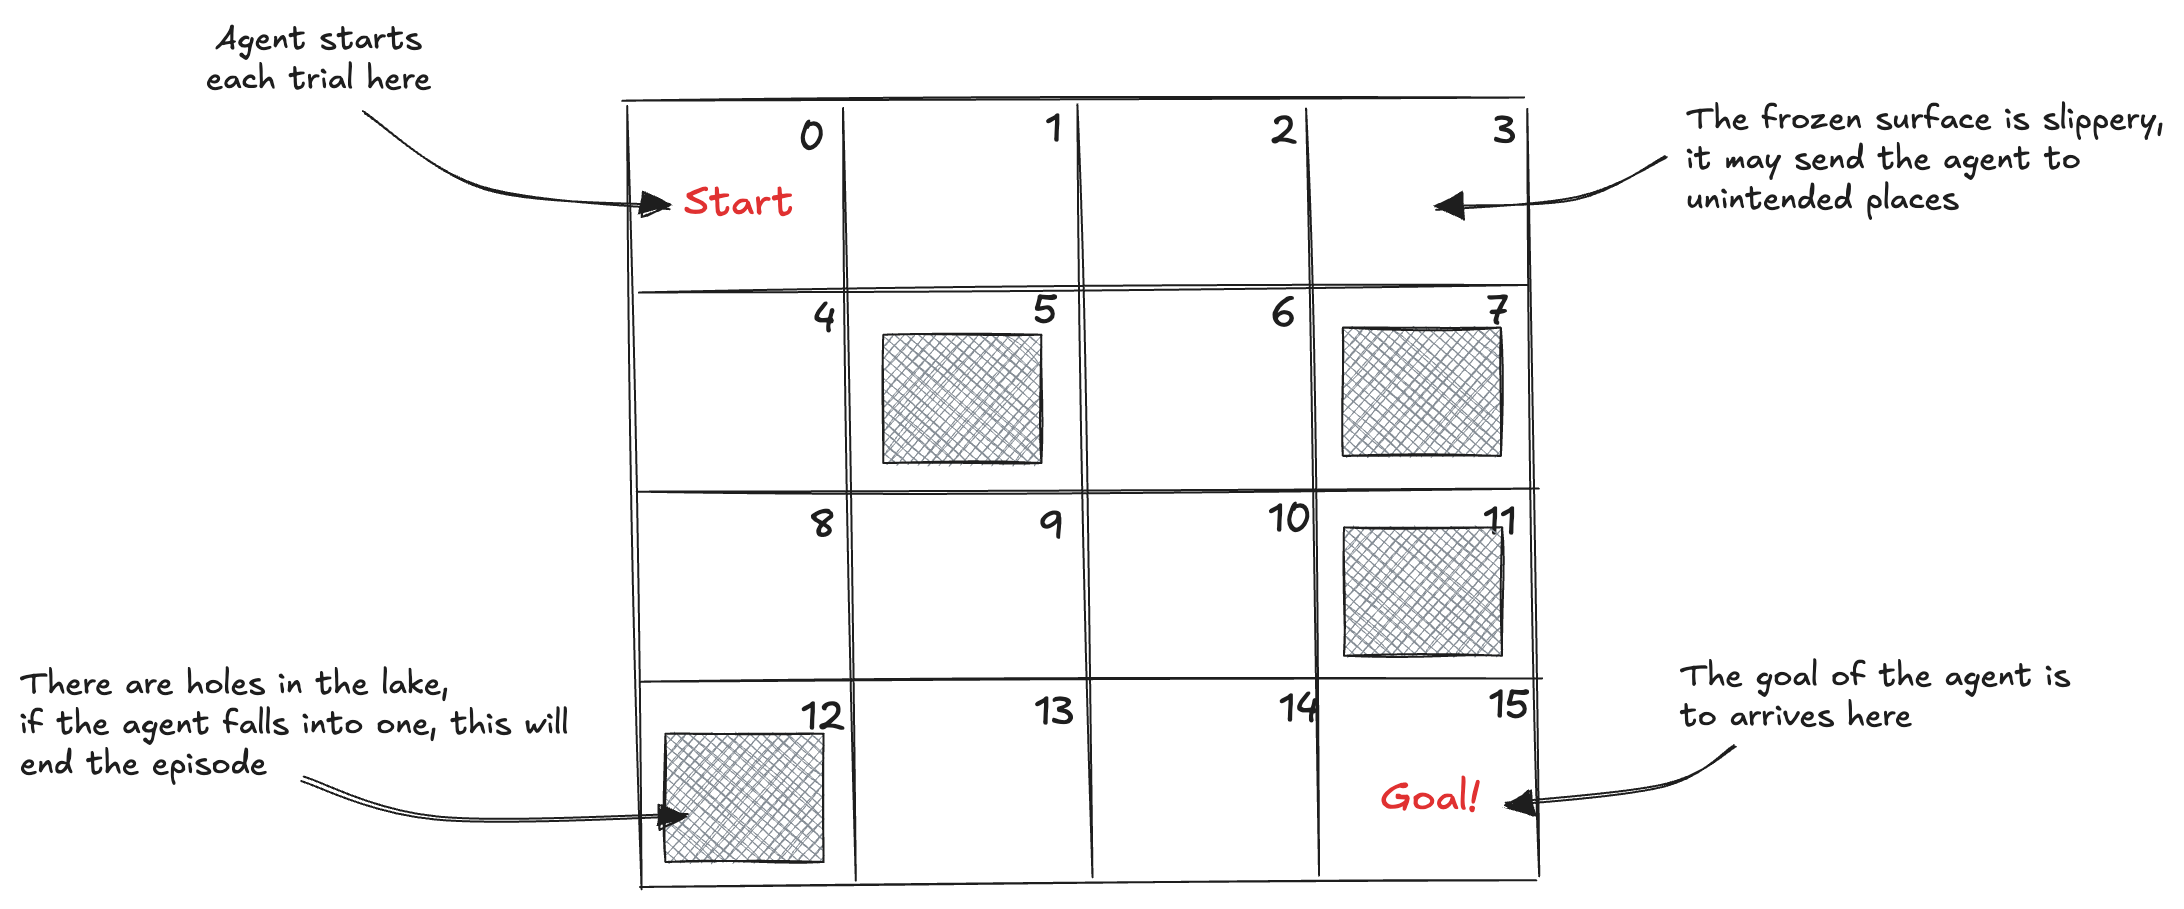

The challenge lies in the **slippery surface** (the environment is stochastic), the agent moves as intended only 33.3% of the time, while the remaining two-thirds are split evenly between orthogonal directions. For instance, if the agent moves down, there's a 33.3% chance it moves left or right instead:

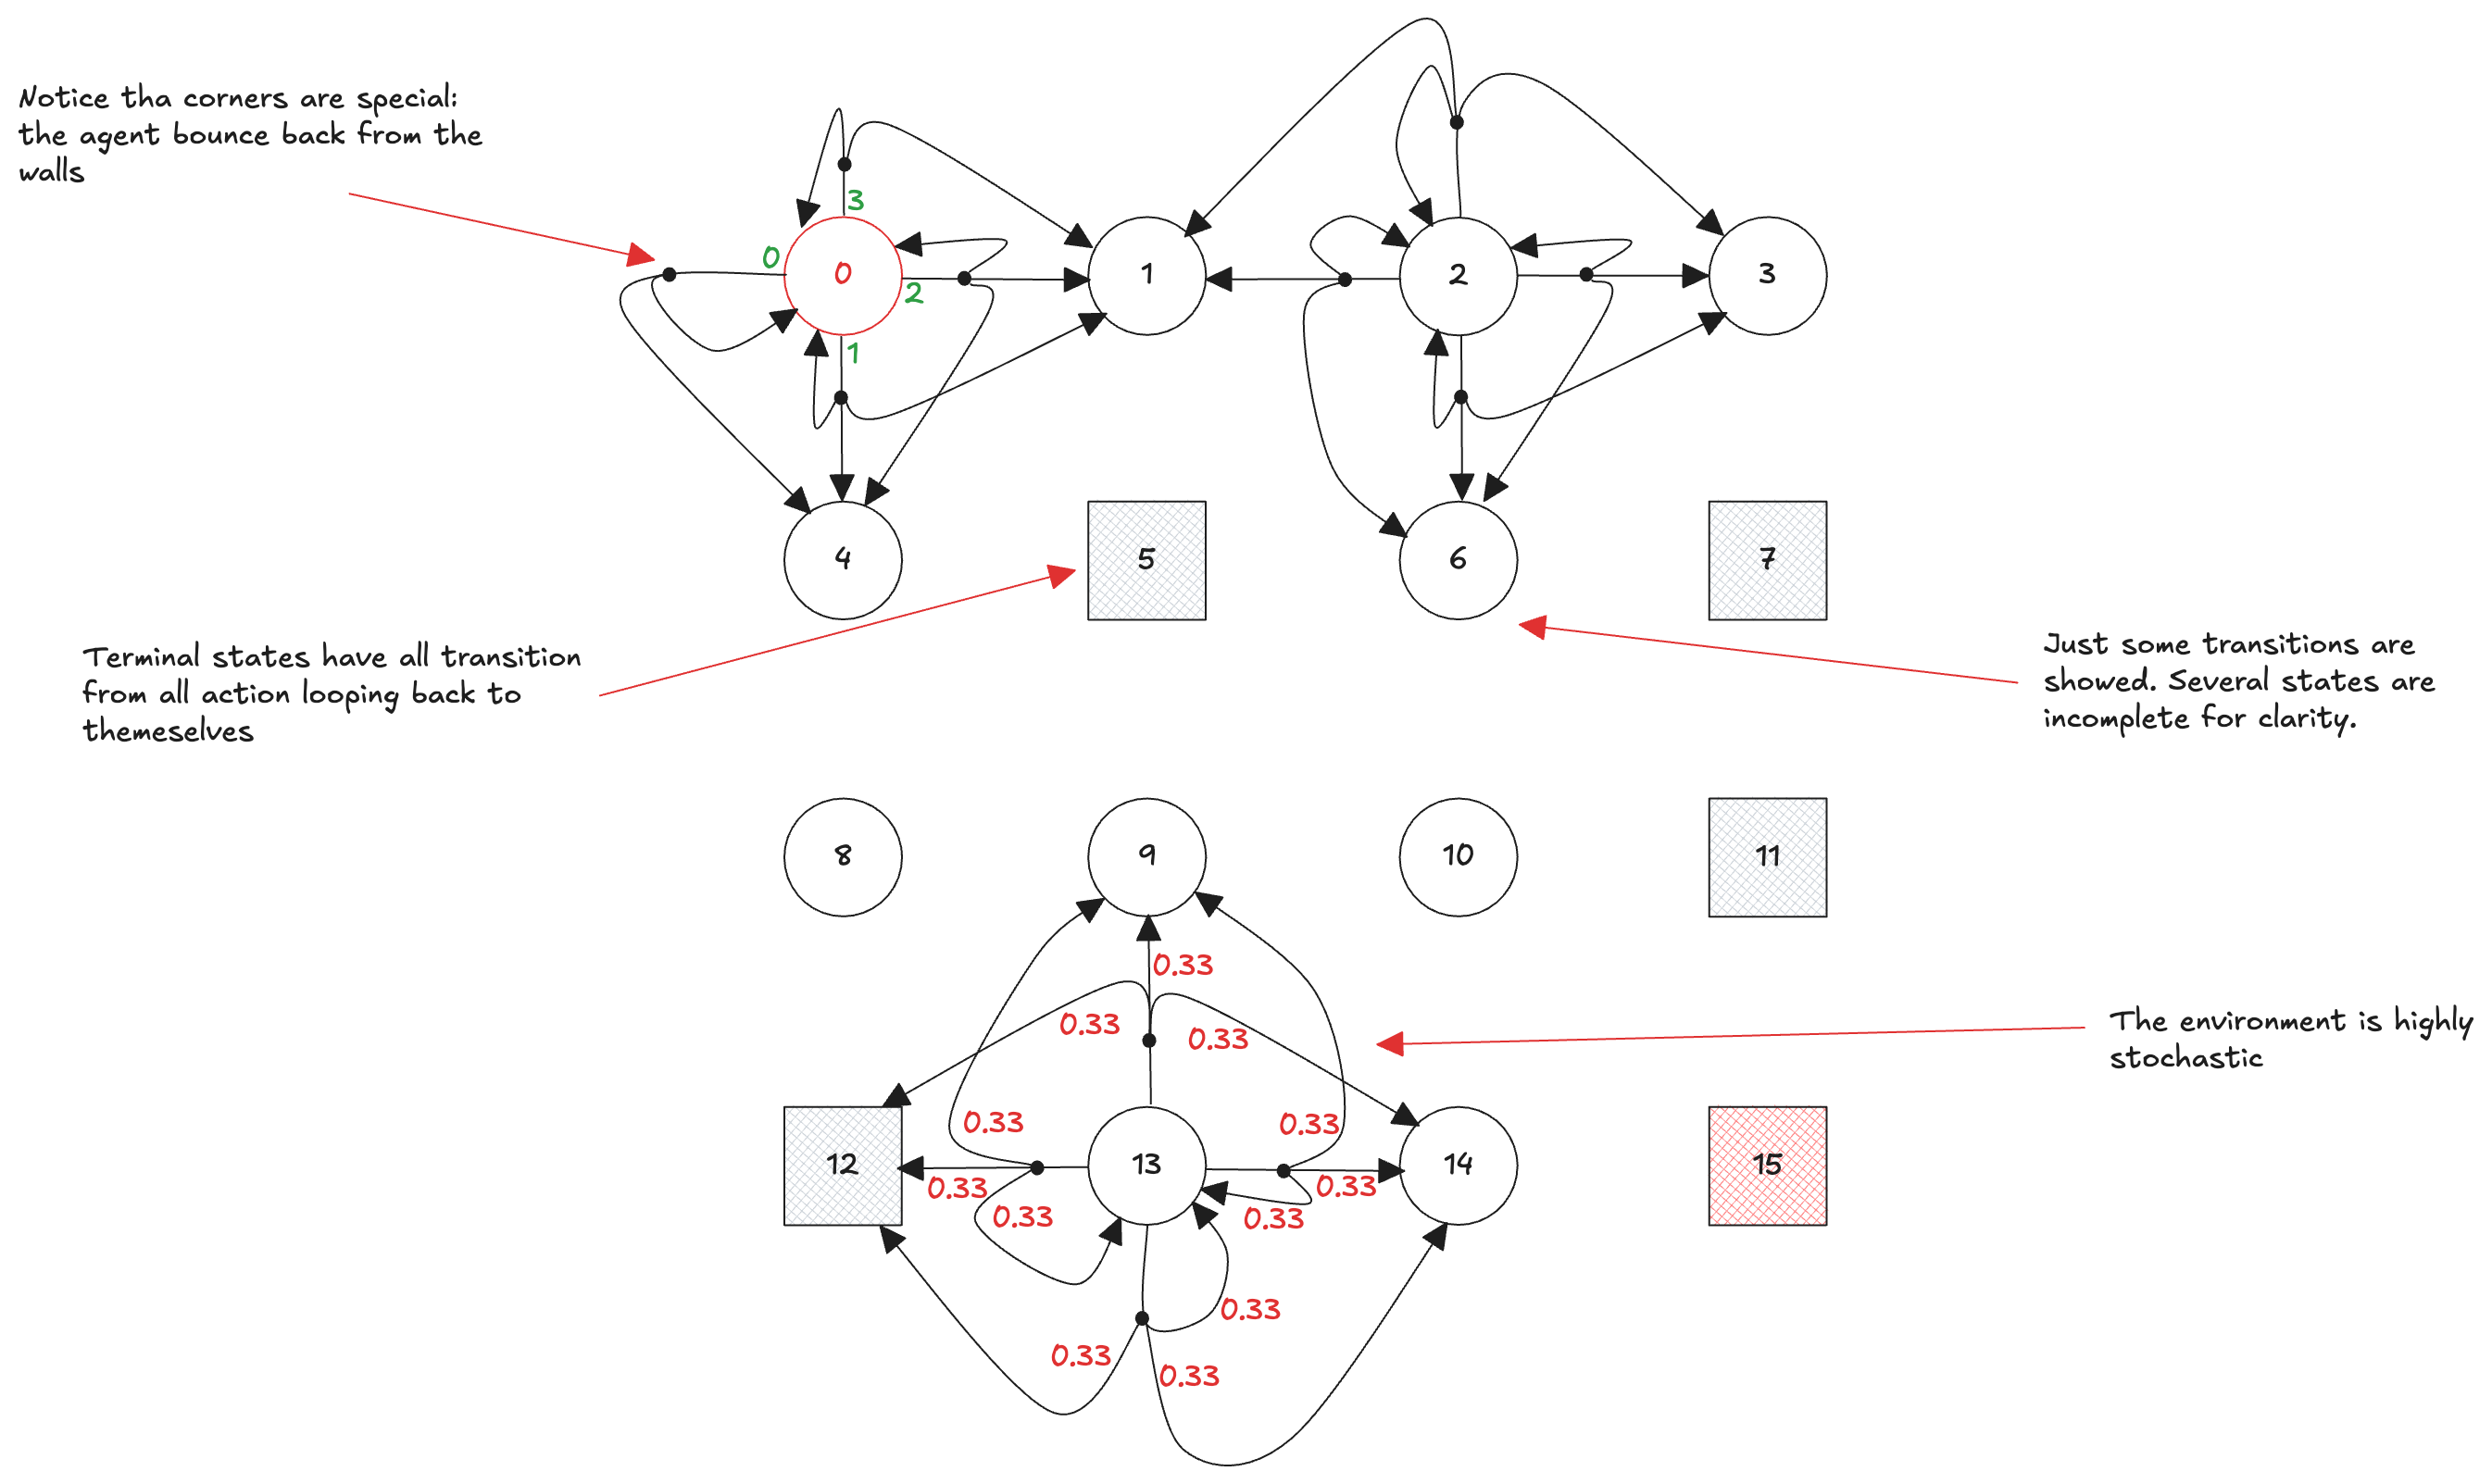

### Policy

It may seem that the agent's goal is to find a sequence of actions, or a **plan**, that maximizes the return (sum of rewards) from the initial state to the target state (at least for an episodic task). If Frozen Lake were deterministic, a solution would be easy: [Right, Right, Down, Down, Down, Right]. Unfortunately, the environment won’t always go along with this solution, because the **actions are unreliable** The plan do not account for the **inherent stochasticity in environments**, and actions may not always have the desired effect. What happens if the agent reaches a state not covered by the plan?

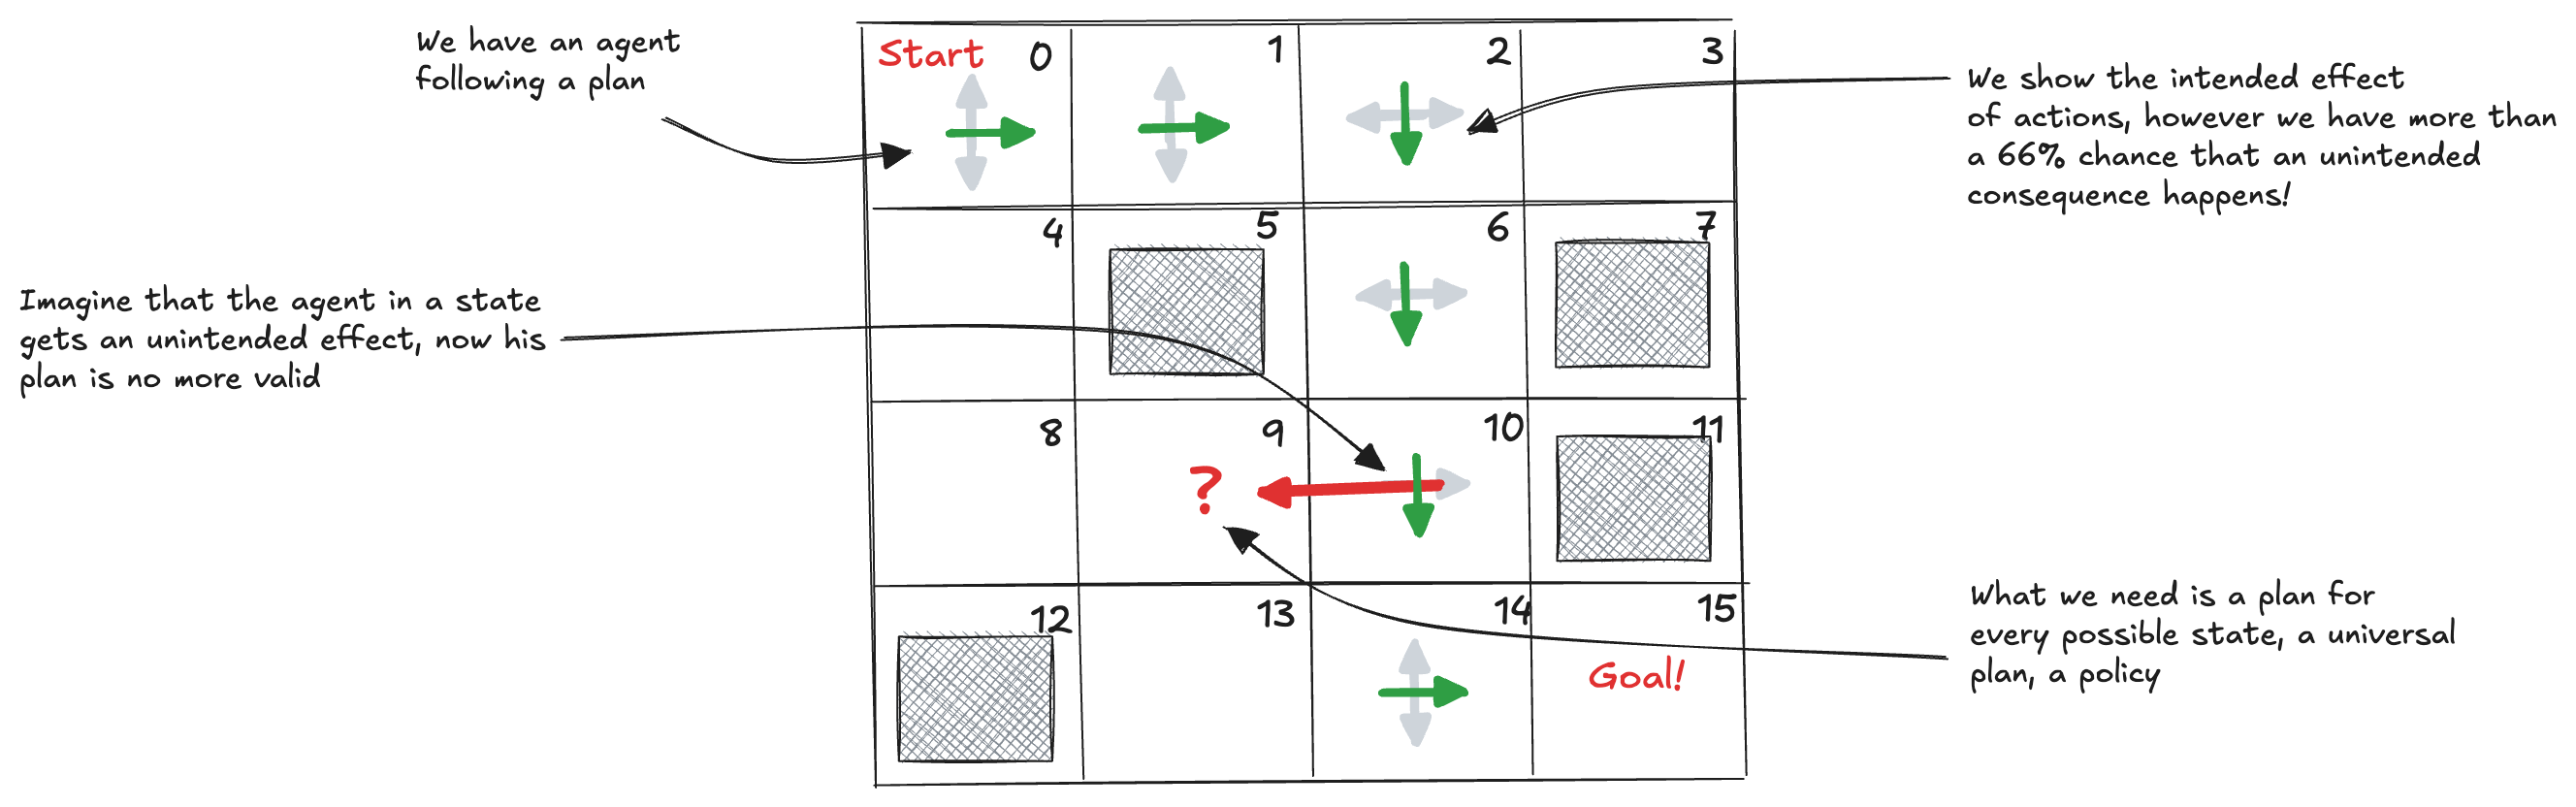

We need a **policy**, a universal plan that covers all possible states. It can be **deterministic** (returns a single actions for a given state) or **stochastic** (returns an action-probability distribution):

$\pi(a|s) = P(A_t=a | S_t=s)$

The problem in Reinforcement Learning is to find a policy that can provide a good solution for the problem. A key question is: **how good is a policy?** How does it compare to another? To answer this, we need to consider the **expected return**, which accounts for the **stochastic nature of the environment**. Even with optimal actions, the environment may lead the agent in unintended directions. Consider the following policies for the frozen-lake environment:

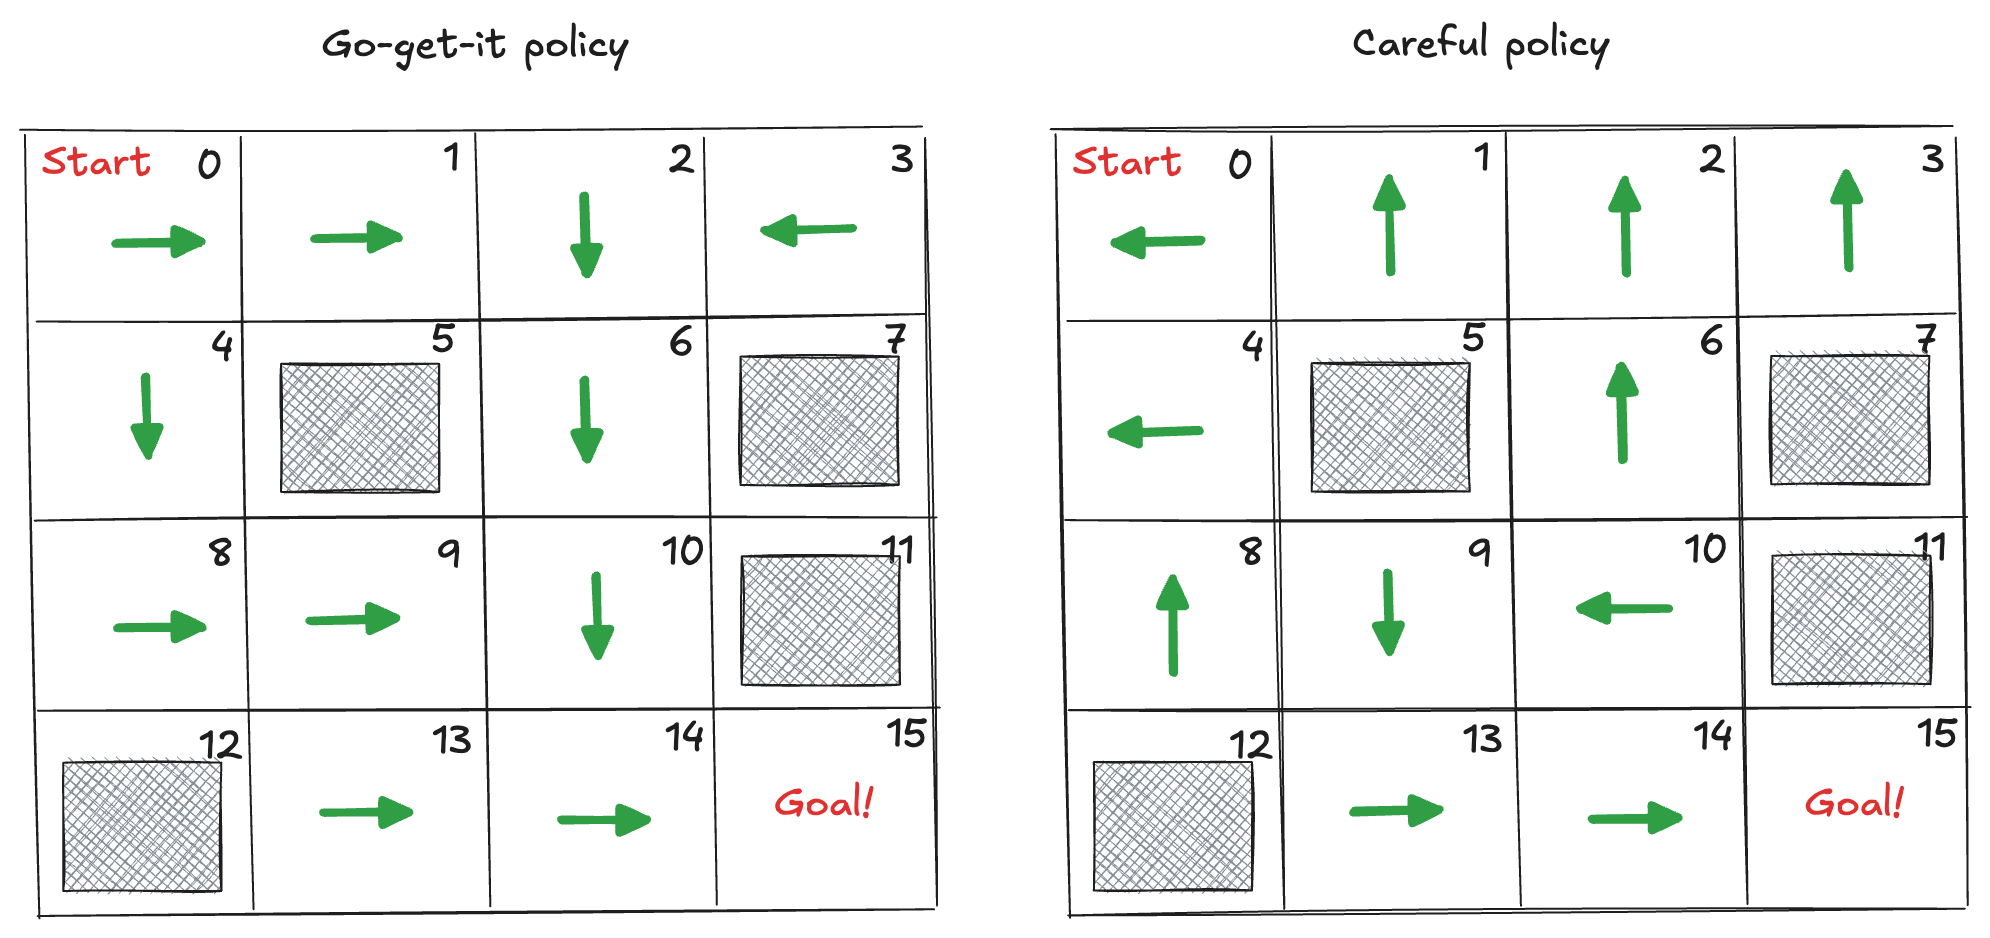

We can implement the two policies in Python:

In [56]:
LEFT, DOWN, RIGHT, UP = range(4)

def go_get_pi(s):
    policy = {
        0: RIGHT, 1: RIGHT, 2: DOWN, 3: LEFT,
        4: DOWN, 5: LEFT, 6: DOWN, 7: LEFT,
        8: RIGHT, 9: RIGHT, 10: DOWN, 11: LEFT,
        12: LEFT, 13: RIGHT, 14: RIGHT, 15: LEFT
    }
    return policy[s]

def careful_pi(s):
    policy = {
        0: LEFT, 1: UP, 2: UP, 3: UP,
        4: LEFT, 5: LEFT, 6: UP, 7: LEFT,
        8: UP, 9: DOWN, 10: LEFT, 11: LEFT,
        12: LEFT, 13: RIGHT, 14: RIGHT, 15: LEFT
    }
    return policy[s]

 A convinient Python library, called [**Gymnasium**](https://gymnasium.farama.org/), provides a huge number of standard environment with shared interfaces for writing general code and testing it. In particular, it provides a unified "Env" class that wraps environments and exposes essential methods like step() and reset(). This abstraction ensures our code remains environment-agnostic:

In [57]:
import gymnasium as gym

# Load the FrozenLake environment
frozen_lake = gym.make('FrozenLake-v1')

We can write a function to show the policy in action:

In [58]:
def show_policy(name, policy, env):
    # Get the grid size from the environment
    grid_size = env.unwrapped.desc.shape[0]  

    # Define the symbols for each action
    action_symbol = {LEFT: '←', DOWN: '↓', RIGHT: '→', UP: '↑'}
    
    # Print the policy name
    print("Policy: ", name)

    # Loop over each cell in the grid
    for row in range(grid_size):
        for col in range(grid_size):

            # Convert the row and col into a state
            state = row * grid_size + col

            # Get the action for this state
            action = policy(state)

            # Print the symbol for the action
            print(action_symbol[action], end="  ")
        
        # Move to the next row
        print() 
    print() 

For example, we can check the two policies in the Frozen Lake environment:

In [59]:
show_policy("Go-get-it", go_get_pi, frozen_lake)
show_policy("Careful", careful_pi, frozen_lake)

Policy:  Go-get-it
→  →  ↓  ←  
↓  ←  ↓  ←  
→  →  ↓  ←  
←  →  →  ←  

Policy:  Careful
←  ↑  ↑  ↑  
←  ←  ↑  ←  
↑  ↓  ←  ←  
←  →  →  ←  



To compare the two policies, we can use a **brute-force approach**: we simulate the interaction between the environment and the agent for an extended period evaluating the probability of success.

In [60]:
import numpy as np

def evaluate(env, pi, n_episodes=10000):

    # Count the number of times the agent reaches the goal
    success = 0

    # Run the episodes
    for _ in range(n_episodes):

        # A flag to indicate whether the episode is done
        done = False    

        # Reset the environment and get the initial state
        state, _ = env.reset()

        # Run the episode
        while not done:
            
            # Make a step in the environment and collect the experience
            new_state, _, terminated, truncated, _ = env.step(pi(state))

            # Check if the episode is done
            if(terminated or truncated):
                done = True;
            
            # Go in the  new state
            state = new_state

        # Check if the agent reached the goal    
        if(state == 15):
            success += 1
            
    # Return the success rate
    return (success/n_episodes)*100

Since the environment is stochastic, an episode might never end. To prevent this, Gymnasium enforces a truncation condition (typically a time limit) to terminate episodes prematurely. Now, we can compare the two policies:

In [61]:
# Evaluate the go_get_pi policy
probability_success = evaluate(frozen_lake, go_get_pi);
print(f"Go-get-it reaches goal {probability_success:.2f}%")

# Evaluate the careful_pi policy
probability_success = evaluate(frozen_lake, careful_pi);
print(f"Careful reaches goal {probability_success:.2f}%")

Go-get-it reaches goal 3.76%
Careful reaches goal 55.20%


Surprisingly, the Go-Get-It policy doesn’t perform well in the Frozen Lake environment!

### The Transition function

The way the environment changes as a response to actions is referred to as  the **transition function**, it maps a transition tuple to a probability:

$(s, a, s') \rightarrow p$ 

Given a state, an action, and a next state, it returns the corresponding probability of transition from that state to the next state when taking that action.

$\displaystyle p(s'| s,a) = P\left(S_t=s'|S_{t-1}=s, A_{t-1}=a\right)$

Notice that the transition function describes a probability distribution determining how the system will evolve in an interaction cycle from selecting actions in states. When integrating over the next states, as any probability distribution, the sum of these probabilities must equal one.

$\displaystyle \sum\limits_{s'\in S}{p(s'|s,a)=1\qquad \text{for all } s \in S, a \in A}$

One key assumption of many problems is that this distribution is **stationary**. That is, while there may be highly stochastic transitions, the probability distribution may not change during training or evaluation. In the Frozen Lake environment, the stationarity assumpimption means that the probability describing the effects of an action in a state is stochastic (33.3% for the intended direction, and the remaining 66.6% split evenly between the orthogonal directions) but remains constant over time. In real situation, the environment may change over time (e.g. the lake surface can be less slippery in sunny days). The **stationary assumption** can be often relaxed to some extent, however, it’s important that environments at least appear to be stationary for long periods of time.

### Markov Property

We assume that the probability of the next state, given the current state and action, is **independent of the history of interactions**. This memory-less property is known as the **Markov property**. The probability of moving from one state to another state on two separate occasions, given the same action, is the same regardless of all previous states or actions encountered before that point:

$\displaystyle P(S_{t+1}|S_t,A_t)=P(S_{t+1}|S_t,A_t,S_{t-1},A_{t-1},...)$

Il the problem holds this property, we say that the problem is a **Markov Decision Process** (MDP). Most agents are designed to take advantage of the Markov assumption, since it simplifies the learning process because the agent doesn't need to remember the entire history of interactions to make decisions. 

In practice, completely keeping the Markov assumption is impractical, perhaps impossible, and we must make sure we **feed our agent the necessary variables to make it hold as tightly as possible**. The more variables we add, the longer it takes to train an agent, but the fewer variables, the higher the chance the information fed to the agent is not sufficient, and the harder it is to learn anything useful.

### The Reward function

To fully define the problem, we must specify the information the agent can exploit to assess the quality of its choices. The **reward function** maps a transition tuple to a numeric signal of the goodness of that transitions:

$(s, a, s') \rightarrow R$ 

A key feature of reinforcement learning is **using a reward signal to define goals**. To guide the agent toward our objectives, we provide rewards that incentivize actions leading to those goals. **It is essential that these rewards clearly reflect the desired outcomes**. Formally, we can define the reward function as the expected value of reward given the state-action-state tuple:
 
$\displaystyle r(s,a,s') = E\left[R_t|S_{t-1}=s, A_{t-1}=a, S_t=s'\right]$

For Frozen Lake problem, the reward is 0 for all transitions except those entering
terminal states, which have rewards +1.

Although goal-setting through rewards may seem limiting, it is highly flexible and effective. Notice that the reward signal should communicates **what** we want the agent to achieve, not **how** to achieve it. Positive rewards can be seen as **incentives or benefits**, while negative rewards serve as **costs, penalties, or punishments**. 

### Experience

The agent follows a three-step process: it interacts with the environment, evaluates its behavior based on the reward feedback, and improves its responses. These interactions occur over multiple **time steps**:

$\displaystyle t=0,1,2,3,...$. 

At each time step, the agent receives some representation of environment state from the state space, and on that basis selects an action from the set of possible actions. One time step later, in part as a consequence of its action, the agent receives a numerical reward and finds itself in a new state. The environment and the agent together give rise to a **trajectory** like this:

$\displaystyle S_0\overset{A_0}{\rightarrow}R_1,S_1\overset{A_1}{\rightarrow}R_2,S_2\overset{A_2}{\rightarrow}R_3,S_3\overset{A_3}{\rightarrow}...R_i,S_i\overset{A_i}{\rightarrow}...$

The combination of state, action, reward, and new state is called an **experience**. Tasks with a natural ending, like a game, are **episodic tasks**, while those without, like learning forward motion, are **continuing tasks**. The sequence of time steps in an episodic task is called an **episode**, and agents may need several time steps and episodes to solve a task:

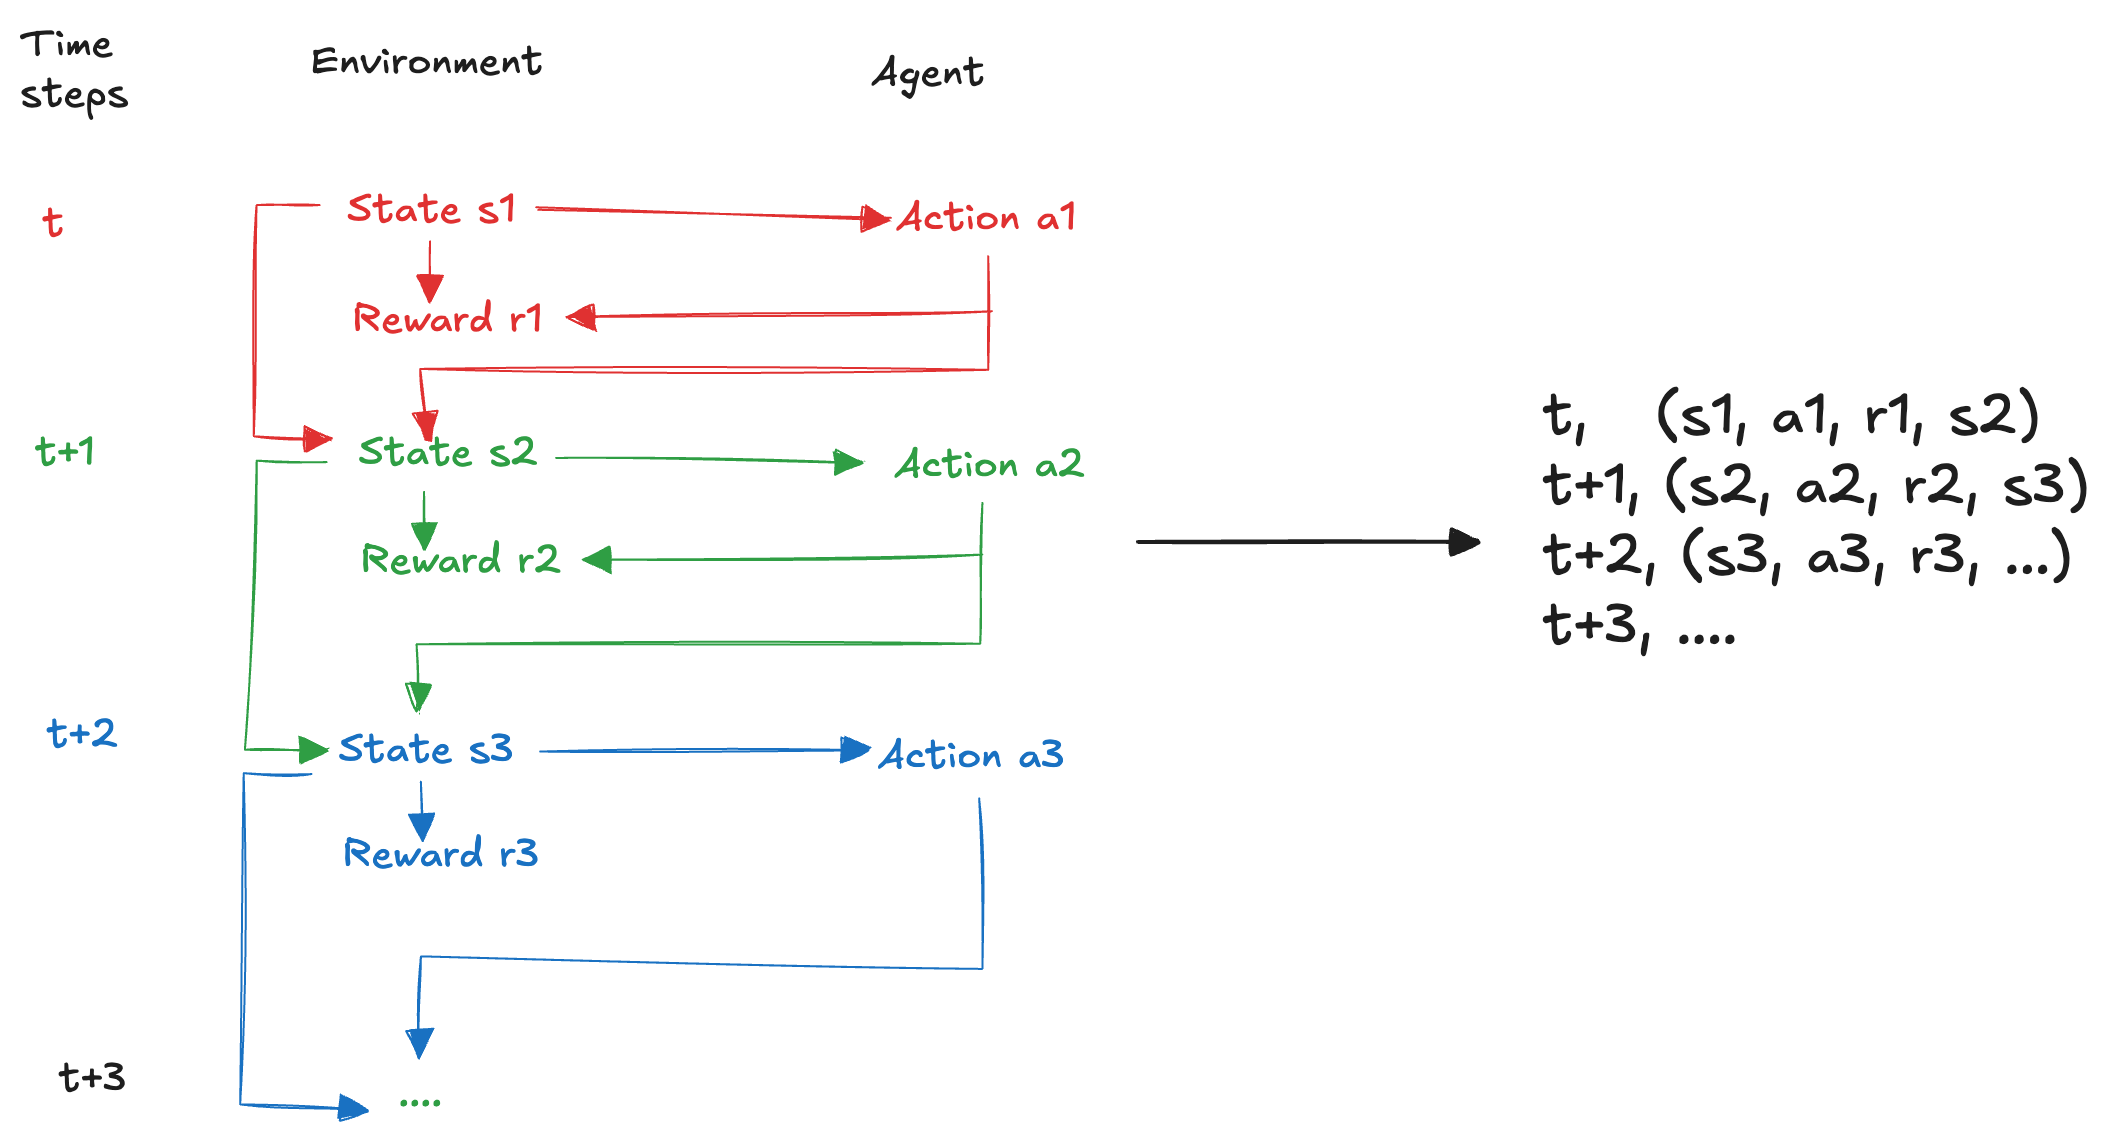

To begin the interaction, we draw a state from a set of the possible **starting states** based on a probability distribution. A **terminal state** is as state in wich all actions lead to it, and these transitions yield no reward.

## Challenges

Balancing immediate and long-term goals is challenging. We experience this point every day: should I watch movies tonight or keep studying reinforcement learning? The first choice has an **immediate satisfaction**, the second on the other hand, won’t really give us much tonight, but **maybe (and only maybe)** will provide much **higher satisfaction in the long term**. We can consider the most important challenges we need to consider in designing an agent in this context.

### Delayed consequences

The agent's actions may have **delayed consequences**, with rewards often being sparse and appearing only after several time steps. This requires the agent to learn from sequential feedback, leading to the **temporal credit assignment problem**: how can the agent determine which state and action were responsible for a given reward?

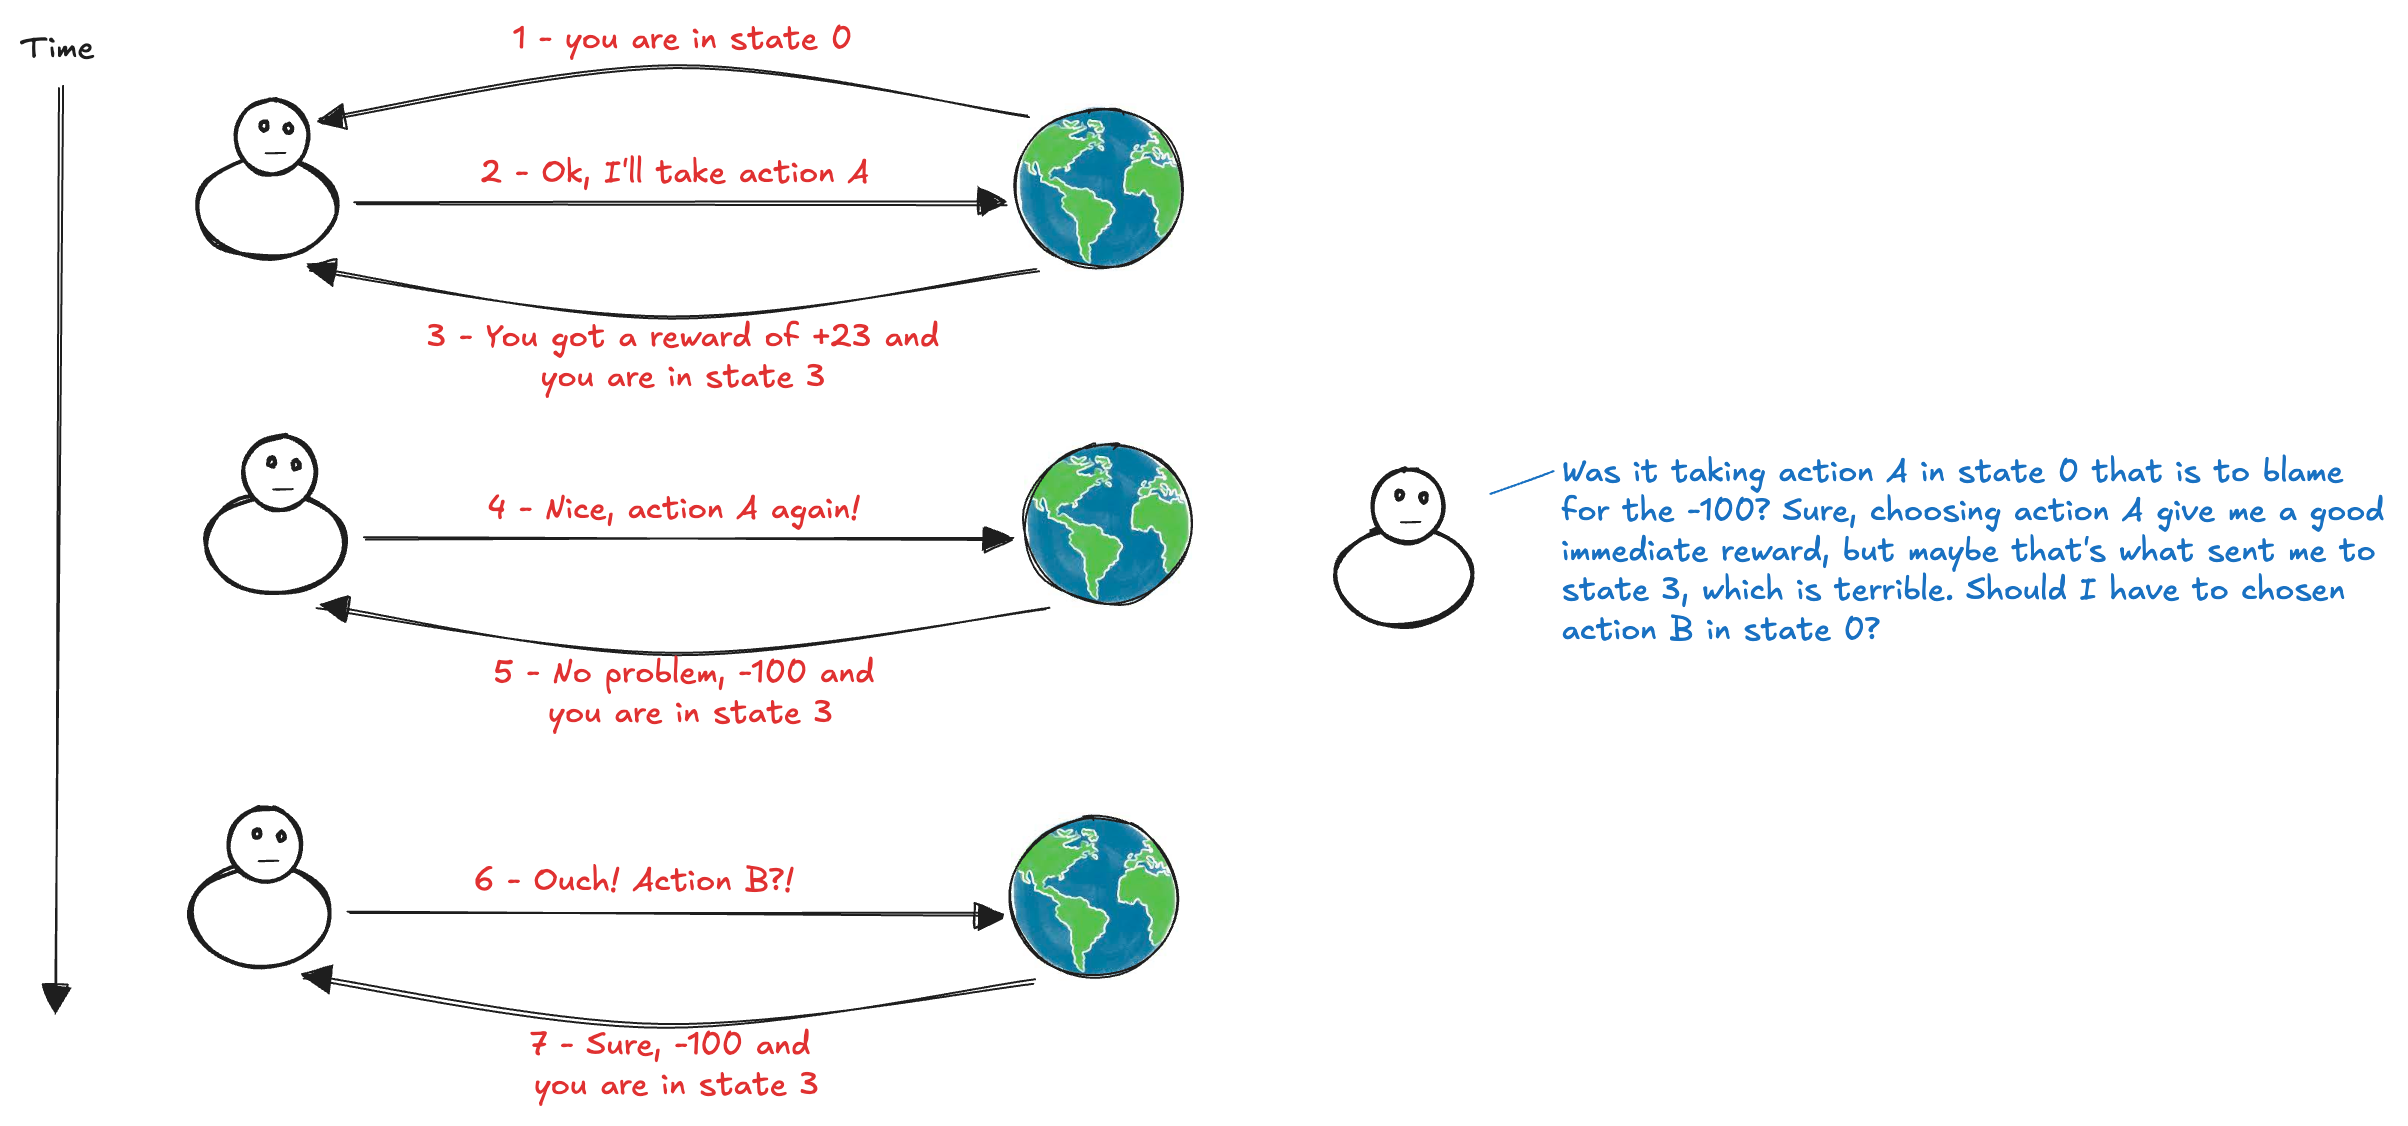

### Exploration and Exploitation

The reward the agent receives is **weak**, as it does not provide direct supervision. It signals **goodness**, but not **correctness**, and offers no information about other possible rewards. Therefore, the agent must learn from **evaluative feedback**, necessitating **exploration**. The agent must balance gathering new information with exploiting what it already knows, which is known as the **exploration versus exploitation trade-off**. This is the same problem faced during the considered in the **multi-armed bandit problem**, which can be considered a simplified version of reinforcement learning with only one state.

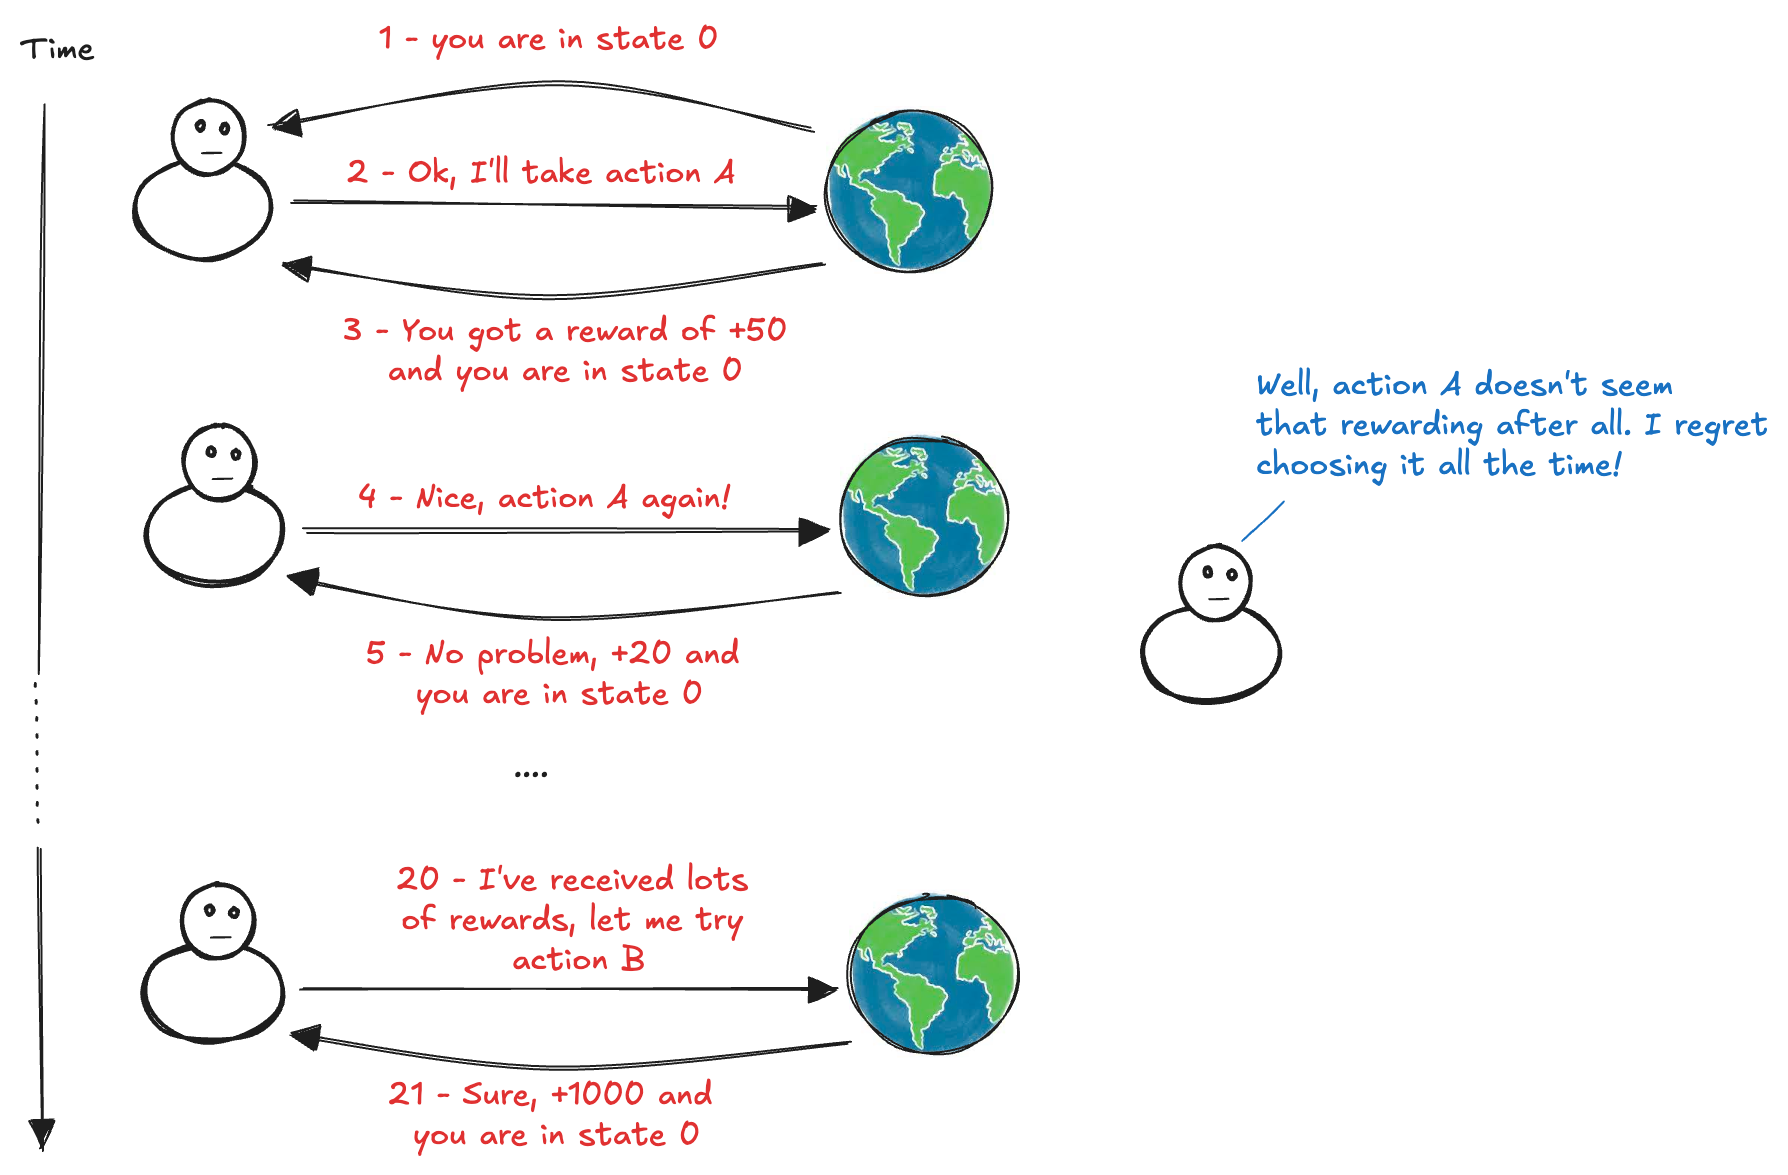

### Sampled feedback

Finally, the reward received by the agent is just a **sample**, and the agent doesn’t have access to the reward function. Also, the state and action spaces are commonly large, even infinite, so trying to learn from **sparse and weak feedback** becomes a harder challenge with samples. Therefore, the agent must be able to learn from sampled feedback, and it must be able to generalize.

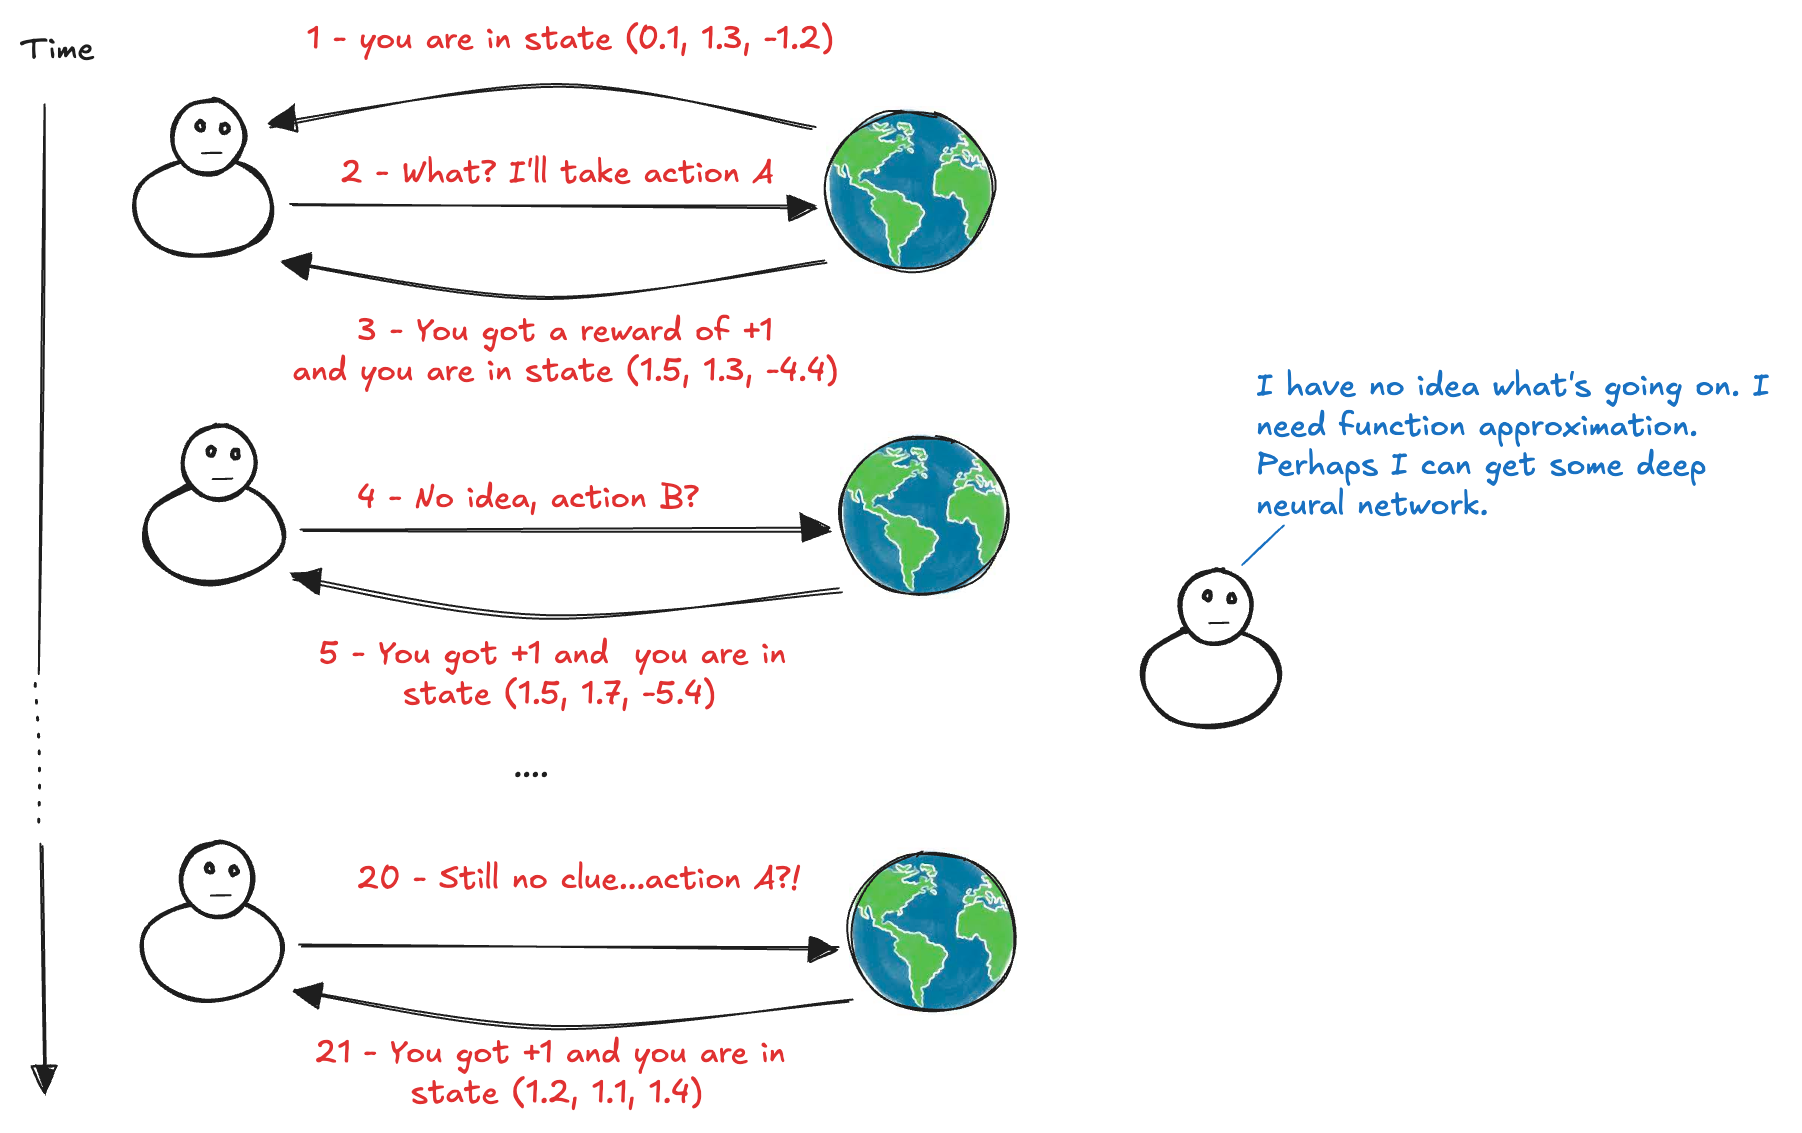

## Learning by trial and error

The MDP framework is **abstract and flexible**, making it applicable to a wide range of problems. Actions can be **low-level**, such as motor voltages in a robot, or **high-level**, like deciding whether to attend graduate school. Similarly, states can range from **raw sensor readings** to **symbolic representations**. In essence, actions represent decisions to learn, and states encompass any relevant information for decision-making. Several extensions adapt MDPs to different RL scenarios, such as the **Partially Observable MDP (POMDP)**, which handles cases where the agent has limited state information, the **Continuous MDP**, which accommodates continuous time, actions, or states, and the **Multi-Agent MDP**, which allows multiple agents to interact within the same environment.

How can we find a good policy for the agent? If we have a perfect model of the environment, knowing both the transition and reward functions, we can use methods like **Dynamic Programming** to compute an optimal policy. However, these methods in some way are "cheating", because they depend on **knowing the dynamics of the environment**, which is something we can’t always obtain. When an agent has full access to an MDP’s internals, there is **no uncertainty**, as it can directly compute expectations. But in real-world problems, the environment’s dynamics are unknown, **life doesn’t hand us its MDP!** and the agent must **learn by interacting with the environment**, which is the essence of **Reinforcement Learning**.

### The Return

The agent's goal is to **maximize the total reward** it receives, focusing not only on immediate rewards but also on **cumulative rewards** over time. The total reward accumulated throughout an episode is known as **the return**:

$\displaystyle  G_t = R_{t+1} + R_{t+2} + R_{t+3} + ... + R_T = \sum\limits_{k=0}^{T}{R_{t+k+1}}$

In episodic tasks, the agent–environment interaction occurs in finite sequences (e.g., playing a game or navigating a maze), with each episode ending in a terminal state and restarting. In continuing tasks, the interaction is ongoing, leading to an infinite summation of rewards (a problem known as **unboundedness**). To handle this, we **discount future rewards**, making rewards received sooner more valuable than those in the future. This is done using a **discount factor**, a positive value less than one, that exponentially reduces the value of future rewards.
 
$\displaystyle G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + ... + \gamma^{T-1} R_T = \sum\limits_{k=0}^{T}{\gamma^k R_{t+k+1}}$

The discount factor is also used to **reduce the variance of return estimates** also for episodic tasks. As the future is uncertain, looking further ahead increases stochasticity and variance in value estimates. By discounting future rewards, the factor limits their impact, stabilizing learning and improving the reliability of value function estimates.

We can rewrite the return in a recursive way, which show that the returns at successive time steps are related to each other:

$\displaystyle  G_t = R_{t+1} + \gamma (R_{t+2}+\gamma R_{t+3} + \gamma^2 R_{t+4}+...) = R_{t+1}+\gamma G_{t+1}$

Notice that we are under stochastic environments, so each time a policy is executed starting from the initial state, the stochastic nature of the environment may lead to a different trajectory. The quality of a policy is therefore measured by the **expected utility of the possible environment trajectory** generated by that policy. Formally, the agent aim is to **maximize the expected return**:

$\displaystyle \max_{\pi} E\left[G_t|\pi\right]$

### State-value function

For a given policy, we can assign a value to each state, helping guide decision-making. By computing the expected return from each state, we can choose actions that lead to higher-value states. This is known as the **state-value function (V-function)**:

$\displaystyle V_{\pi}(s)=E_{\pi}\left[G_t|S_t=s\right]$

This value isn’t straightforward to calculate, because of the dependence on the values of other states. For example, if we follow the Go-get-it policy starting from state 14, we get the following value:

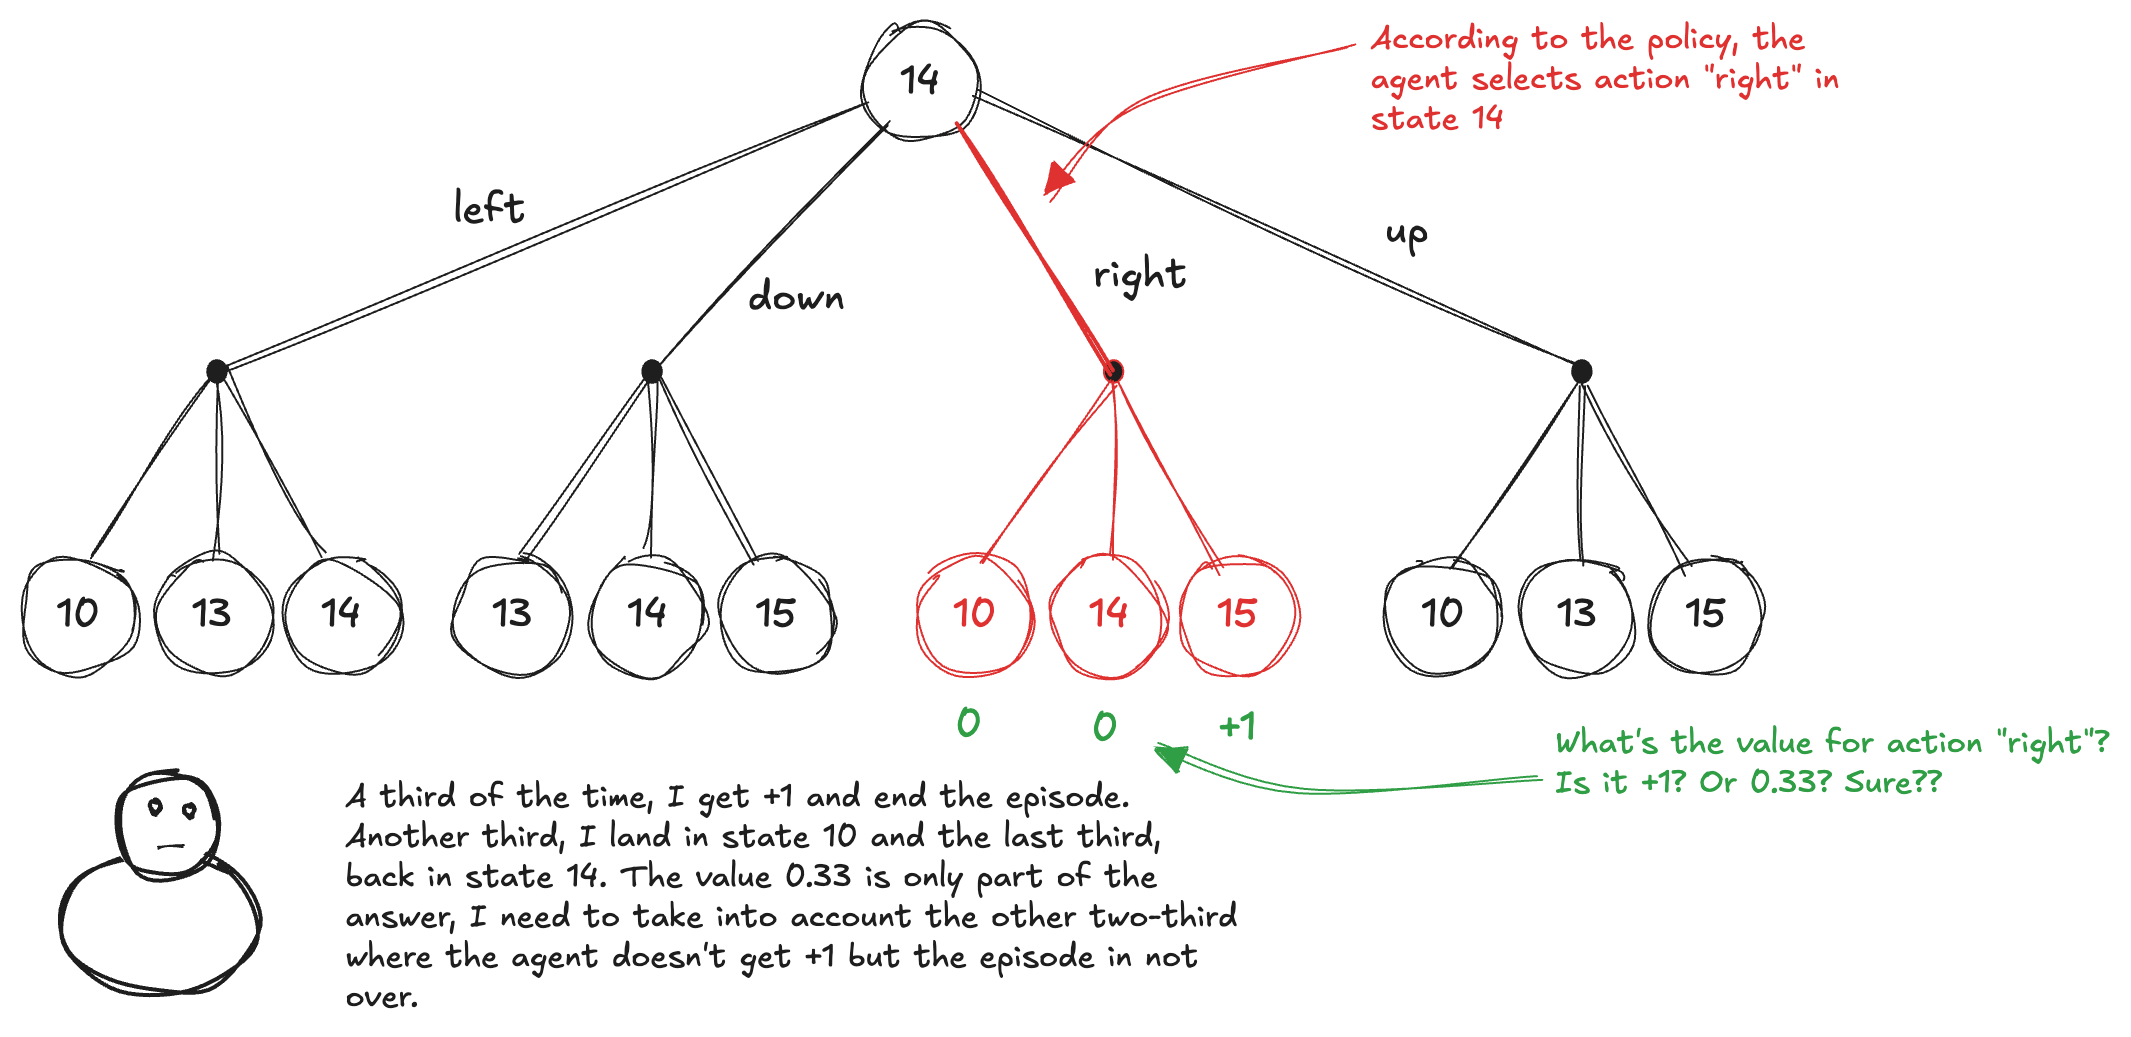

We can use the recursive definition of the return:

$\displaystyle V_{\pi}(s)=E_{\pi}\left[R_{t+1} + \gamma G_{t+1} | S_t=s \right]$

and applying the defintion of the value function on the next state:

$\displaystyle V_{\pi}(s) = E_{\pi}\left[R_{t+1} + \gamma V_{\pi}(S_{t+1}) | S_t=s \right]$

This equation is known as the **Bellman equation** for the state-value function. It relates the value of a state to the immediate reward and the value of the next state.

### Action-value function

The critical question is not merely about the value of a state, but the value of taking an action in a state. The **action-value function (Q-function)** captures precisely this, the expected return if the agent follows a policy after taking an action in a state:

$\displaystyle Q_{\pi}(s,a)=E_{\pi}(G_t|S_t=s, A_t=a)$

With can provide a formulation of the Bellman equation also for the action-value function with similar reasoning:

$\displaystyle Q_{\pi}(s,a) = E_{\pi}\left[R_{t+1} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) | S_t=s, A_t=a \right]$

This is another version of the Bellman equation. It relates the value of taking an action in a state to the immediate reward and the value of the next state-action pair.

### Optimal Policies

An **optimal policy** in reinforcement learning is a policy that maximizes the expected return from any given state. Formally, a policy is optimal if its state-value function is greater than or equal to that of any other policy for all states:  

$\displaystyle \pi^* \geq \pi \, \forall \pi \, \Leftrightarrow \, V_{\pi^*}(s) \geq V_{\pi}(s), \, \forall s$

Similarly, in terms of action-value functions, an optimal policy satisfies:  

$\displaystyle Q_{\pi^*}(s,a) \geq Q_{\pi}(s,a), \, \forall s, a$

### Q-Learning

How can we find an optimal policy? Suppose we have already determined the value function for a given policy. For a specific state, we may want to know whether we should deviate from the policy by choosing an action different from the one prescribed by the current policy. In other words, should we follow a different policy? While we know the quality of following the current policy (as indicated by the value function), is there a potentially better alternative? To answer this, we can evaluate the possibility of selecting an alternative action, then continuing to follow the current policy afterward, and compute the action-value function under this new assumption. If the value of this new action is greater, it would be better to choose the new action in that state, rather than following the current policy. This is an example of the **policy improvement theorem**:

$\displaystyle Q_{\pi}(s,\pi'(s)) \geq V_{\pi}(s) \enspace \forall s \in S \, \Rightarrow \, V_{\pi'}(s) \geq V_{\pi}(s)$

The Q-learning algorithm leverages this concept to iteratively improve the action-value function and learn the optimal policy. The agent maintains a Q-table which estimates the quality of taking actions in states following the optimal policy. Initially, the Q-table is set to random values (often zero). The agent interacts with the environment, balancing exploration (trying new actions) and exploitation (choosing actions with high rewards), and receives an immediate reward and the next state. The agent calculates the **Temporal Difference (TD) error**:

$\displaystyle \delta = R_{t+1} + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t)$

This error measures the difference between the current Q-value estimate and the new estimate after taking the action. The TD error reflects how surprised the agent is by the new information. The agent then updates the old Q-table value by adding a fraction (determined by **learning rate $\beta$**) of the TD error:

$\displaystyle Q(s_t,a_t) = Q(s_t,a_t) + \beta \left[ R_{t+1} + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t) \right]$

If the new information suggests the selected action is more rewarding than previously estimated, the Q-value increases; if it suggests the action is less rewarding, the value decreases. By continuously refining the Q-table based on new experiences, the algorithm converges towards the optimal action-value function, and once this function is accurately estimated, the optimal policy can be derived by choosing the action that maximizes the Q-value for each state.

As an algorithm to balance exploration and exploitation, we can use the **epsilon-greedy policy**:

In [62]:
def select_action(state, Q, epsilon):

    # If the random number is greater than epsilon, 
    if np.random.uniform() > epsilon:
        # Pick the action with the highest Q value
        action = np.argmax(Q[state]);
    else:
        # Otherwise, pick a random action
        action = np.random.randint(len(Q[0]));
        
    return action;

We can implement the Q-learning algorithm in Python:

In [63]:
def q_learning(env, gamma=0.99, beta=0.01, epsilon=0.5, n_episodes=50000):
    
    # Initialize the current estimate of the action-value function
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float);
    
    # Create a list to save copies of V for offline analysis
    V_track = np.zeros((n_episodes, env.observation_space.n), dtype=float);
    
    # Run the episodes    
    for e in range(n_episodes):

        # Reset the environment and get the initial state
        state, done = env.reset()[0], False;

        # Run the episode
        while not done:

            # Select an action balancing exploration and exploitation
            action = select_action(state, Q, epsilon);

            # Take a step in the environment
            next_state, reward, terminated, truncated, _ = env.step(action);

            # Check if the episode is done
            if(terminated or truncated):
                done = True;
            
            # Calculate the TD error
            td_error = reward + gamma * Q[next_state].max() - Q[state][action];

            # Update the action-value function
            Q[state][action] = Q[state][action] + beta * td_error;

            # Move to the next state
            state = next_state;

        # Extract the value function and save it for offline analysis 
        V_track[e] = np.max(Q, axis=1);
    
    # Define the policy
    def pi(s):
        return np.argmax(Q[s]);

    return pi, Q, V_track;

We can apply Q-learning to the Frozen Lake environment:

In [64]:
frozen_lake = gym.make('FrozenLake-v1')
pi, Q, V_track = q_learning(frozen_lake)

And we can evaluate the performance of the obtained policy:

In [65]:
probability_success = evaluate(frozen_lake, pi);
print(f"Learned policy reaches goal {probability_success:.2f}%")

Learned policy reaches goal 74.59%


This policy is better than the Careful policy. Let's visualize the learned policy:

In [66]:
show_policy("Learned", pi, frozen_lake)

Policy:  Learned
←  ↑  ↑  ↑  
←  ←  ←  ←  
↑  ↓  ←  ←  
←  →  ↓  ←  



In [67]:
V_track.shape

(50000, 16)

We can also visualize the state value learned by the Q-learning algorithm after each episode for some states, like 0, 3, 4 and 14:

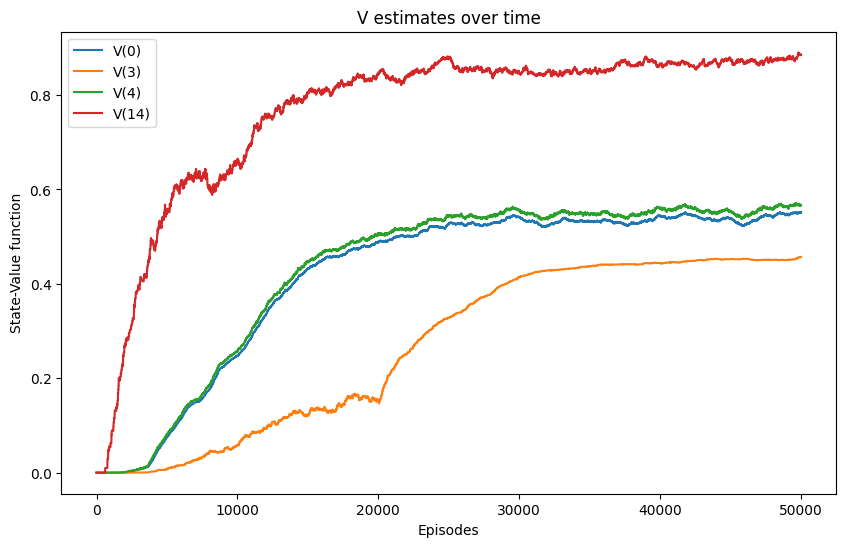

In [68]:
import matplotlib.pyplot as plt

# Filter the V_track to only include states 0, 3, 4, and 14
states_to_plot = [0, 3, 4, 14]
V_filtered = V_track[:, states_to_plot]

# Create the plot
plt.figure(figsize=(10,6))
plt.plot(V_filtered)
plt.title('V estimates over time')
plt.ylabel('State-Value function')
plt.xlabel('Episodes')
legends = ['V(0)', 'V(3)', 'V(4)', 'V(14)']
plt.legend(legends)

# Show the plot
plt.show()


The figure provides a clear visualization of the Q-learning process in Frozen Lake. It shows how the algorithm learns the value of different states over time, ultimately leading to an understanding of the optimal path to the goal.  The rapid convergence of state 14 value highlights its importance, while the slower convergence of other states indicates their relative distance or difficulty in reaching the goal.

### Taxi

A slightly more complex environment is the **Taxi environment**, where the problem involves navigating passengers in a grid world, picking them up and dropping them off at one of four locations (Red, Green, Yellow and Blue) in a 5x5 grid world. The agent can move in four directions and perform six actions: pick up, drop off, and move in each direction:

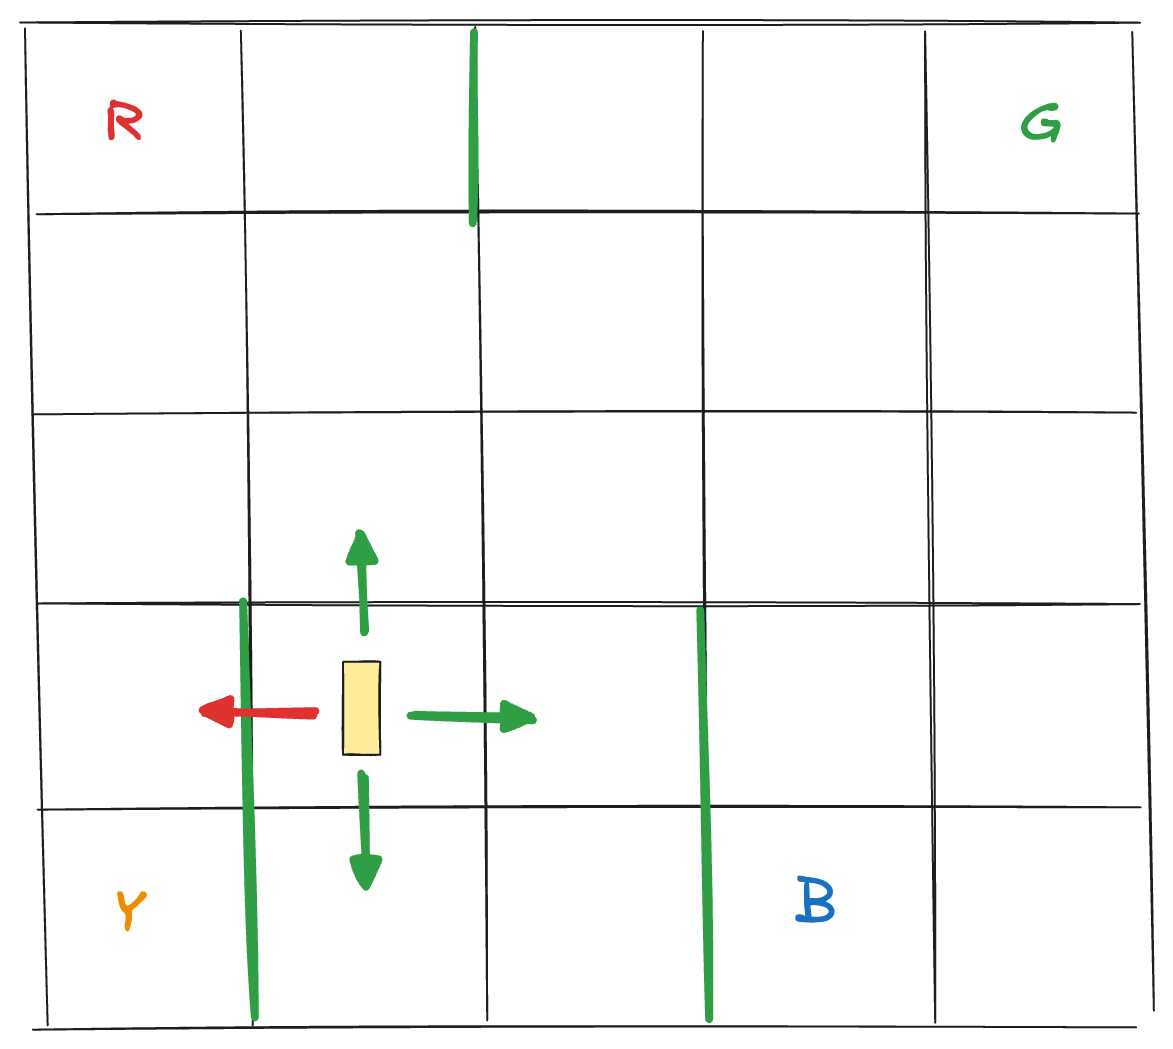

The state is described by the taxi location on the grid (a row and a column number between 0 and 4), a location to drop-off the passenger from four choices, and the passenger which can be in one of the four locations or inside the taxi, in total 500 discrete states. An observation is returned as an int that encodes the corresponding state, calculated by: 

((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination

The player receives positive rewards for successfully dropping-off the passenger at the correct location. Negative rewards for incorrect attempts to pick-up/drop-off passenger and for each step where another reward is not received. We can use Q-learning to solve the Taxi environment:

In [69]:
taxi = gym.make('Taxi-v3', render_mode="rgb_array")
pi, Q, V_track = q_learning(taxi)

The Gymnasium library provides a simple interface to get an image of the state of the environment, we can exploit this to visualize an episode:

In [54]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_episodes(env, pi, n_episodes=1):

    # Run the episodes
    for _ in range(n_episodes):

        # Reset the environment and get the initial state
        state, info = env.reset()

        # A flag to indicate whether the episode is done
        done = False

        # Run the episode
        while not done:

            # Select an action using the policy
            action = pi(state);

            # Take a step in the environment
            state, _, terminated, truncated, _ = env.step(action)

            # Check if the episode is done
            if(terminated or truncated):
                done = True;

            # Display the environment    
            clear_output(wait=True)
            plt.imshow(env.render())
            plt.show()

            # Pause for a short time
            time.sleep(0.5)

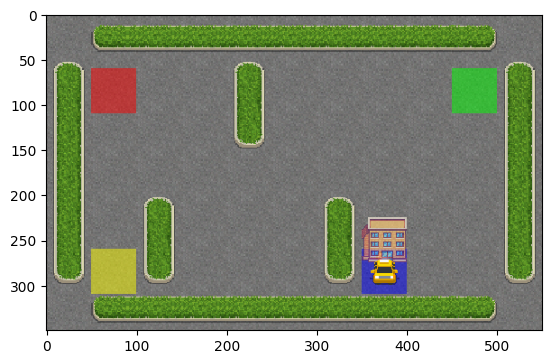

In [71]:
show_episodes(taxi, pi)